# **Project Name**    - **Zomato Restaurant Clustering**



##### **Project Type**    - Unsupervised
##### **Contribution**    - Indivisual
##### **Team Member 1 -** - SAGAR JAIN


# **Project Summary -**

The objective of this project was to analyze Zomato restaurant data and identify meaningful patterns that can help understand restaurant performance and customer behavior. With the rapid growth of the restaurant industry and the large number of restaurants listed on online platforms such as Zomato, it becomes challenging for both customers and businesses to analyze restaurant characteristics and performance trends. Therefore, this project aimed to segment restaurants into different groups using clustering techniques based on factors such as pricing, customer ratings, review behavior, and textual feedback from customers.

The dataset consisted of restaurant metadata along with customer reviews. The metadata included features such as restaurant name, cost, ratings, and review-related statistics, while the review dataset contained textual feedback provided by customers. Since the review data was in textual form, Natural Language Processing (NLP) techniques were applied to convert the text into numerical features that could be used in machine learning models. The preprocessing of text involved steps such as lowercasing, removing punctuation, eliminating stopwords, and applying lemmatization to normalize the text data.

To convert textual reviews into numerical representations, the Term Frequency–Inverse Document Frequency (TF-IDF) technique was used. TF-IDF helps measure the importance of words in a collection of documents by assigning higher weights to words that are more relevant in specific reviews while reducing the influence of very common words. However, TF-IDF generated a very high number of features (around 999), which increased the dimensionality of the dataset and could negatively impact clustering performance.

To address this issue, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the TF-IDF features. PCA transformed the large set of text features into a smaller number of principal components while retaining most of the important information present in the original data. This step reduced the feature space significantly while preserving approximately 67.9% of the variance in the data.

After feature engineering and dimensionality reduction, the dataset was scaled using StandardScaler to ensure that all features contributed equally during the clustering process. Since clustering algorithms rely heavily on distance calculations, scaling was essential to prevent features with larger values, such as cost, from dominating the clustering results.

Three clustering models were implemented and compared in this project: KMeans Clustering, Agglomerative Hierarchical Clustering, and Gaussian Mixture Model (GMM). Each model was first trained as a baseline and then tuned to improve clustering performance. The models were evaluated using the Silhouette Score, which measures how well each data point fits within its assigned cluster compared to other clusters. A higher silhouette score indicates better-defined and well-separated clusters.

Among the three models tested, the tuned Agglomerative Hierarchical Clustering model produced the best results, achieving a silhouette score of approximately 0.5566, which indicates strong cluster separation. The KMeans model achieved a lower silhouette score of around 0.2168, while the Gaussian Mixture Model achieved approximately 0.4457.

The clustering analysis successfully segmented restaurants into meaningful groups based on attributes such as cost, ratings, review count, and review characteristics. These clusters represent different types of restaurants in terms of pricing strategies, customer engagement, and perceived quality. By examining the characteristics of each cluster, it becomes possible to better understand how restaurants differ in terms of customer perception and performance.

Overall, the project demonstrates how combining restaurant metadata with customer review analysis and applying clustering techniques can help uncover hidden patterns in restaurant data. The results provide valuable insights into restaurant segmentation and customer behavior, helping to better understand how different types of restaurants are positioned within the dataset.

# **GitHub Link -**

https://github.com/Sagarjain93/Machine-Learning-Portfolio/tree/main/03_ML_Practice/Zomato_Restaurant_Clustering

# **Problem Statement**


The Indian restaurant industry is growing rapidly, with thousands of restaurants listed on Zomato across different cities. Customers rely heavily on ratings, reviews, pricing, and services like online delivery and table booking to choose restaurants.

However, with such a large number of restaurants, it becomes difficult:

*  For customers to identify the best restaurant based on their preferences.

*  For Zomato to understand restaurant performance patterns across cities.

*  To categorize restaurants into meaningful business segments.

This project aims to analyze Zomato restaurant data to:

*  Understand customer behavior through ratings and reviews.

*  Identify important factors affecting restaurant performance.

*  Segment restaurants into different clusters based on features like cost, ratings, and services.

*  Provide actionable business insights that can help customers make better decisions and help Zomato improve strategic planning.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [255]:
# ==============================
# Install Required External Packages
# ==============================

!pip install contractions

In [289]:
# ==============================
# Basic Libraries
# ==============================

import numpy as np
import pandas as pd

# ==============================
# Visualization Libraries
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ==============================
# Statistical Libraries (Hypothesis Testing)
# ==============================

from scipy.stats import pearsonr
from scipy.stats import ttest_ind

# ==============================
# NLP Libraries
# ==============================

import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# ==============================
# Feature Engineering
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# Clustering Models
# ==============================

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

# ==============================
# Evaluation Metric
# ==============================

from sklearn.metrics import silhouette_score

# ==============================
# Hierarchical Clustering Visualization
# ==============================

from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================
# DBSCAN Parameter Tuning
# ==============================

from sklearn.neighbors import NearestNeighbors

# ==============================
# Warnings
# ==============================

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [132]:
# Clone my GitHub repository
!git clone "https://github.com/Sagarjain93/Machine-Learning-Portfolio.git"

fatal: destination path 'Machine-Learning-Portfolio' already exists and is not an empty directory.


In [133]:
# Define base path
base_path = "Machine-Learning-Portfolio/03_ML_Practice/Zomato_Restaurant_Clustering/raw_data/"

# Load metadata dataset
metadata_df = pd.read_csv(base_path + "Zomato Restaurant names and Metadata.csv")

# Load reviews dataset
reviews_df = pd.read_csv(base_path + "Zomato Restaurant reviews.csv")


### Dataset First View

In [134]:
# Dataset First Look
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [135]:
# Dataset First Look
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [136]:
metadata_df.shape

(105, 6)

In [137]:
reviews_df.shape

(10000, 7)

In [138]:
# Dataset Rows & Columns count
print("="*60)
print(" DATASET SHAPE SUMMARY")
print("="*60)

print("\n  METADATA DATASET")
print(f"   ➤ Rows    : {metadata_df.shape[0]:,}")
print(f"   ➤ Columns : {metadata_df.shape[1]}")

print("\n REVIEWS DATASET")
print(f"   ➤ Rows    : {reviews_df.shape[0]:,}")
print(f"   ➤ Columns : {reviews_df.shape[1]}")

print("\n" + "="*60)

 DATASET SHAPE SUMMARY

  METADATA DATASET
   ➤ Rows    : 105
   ➤ Columns : 6

 REVIEWS DATASET
   ➤ Rows    : 10,000
   ➤ Columns : 7



### Dataset Information

In [139]:
# Dataset Info
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


**Important Observations:**

*  All columns are object type
    → Even Cost is stored as text (not numeric).
    → We will need to convert it later.

*  Missing Values:

    Collections → Only 51 non-null out of 105
    → Almost 50% missing

*  Timings → 1 value missing

*  Small dataset (105 restaurants only)

In [140]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


**Important Observations:**

*  Missing values:

    Reviewer → 38 missing

    Review → 45 missing

    Rating → 38 missing

    Metadata → 38 missing

    Time → 38 missing

*  Rating is object type
    → Should be numeric
    → Might contain text like "Rated 4.0"

*  Pictures is already numeric (int64)

#### Duplicate Values

In [141]:
# Dataset Duplicate Value Count
metadata_df.duplicated().sum()

np.int64(0)

In [142]:
reviews_df.duplicated().sum()

np.int64(36)

#### Missing Values/Null Values

In [143]:
# Missing Values in metadata dataset
metadata_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [144]:
# Missing Values in reviews dataset
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [145]:
# Value Counts in metadata and review dataset
print("="*50)
print("NULL VALUE COUNT - METADATA DATASET")
print("="*50)

meta_null = metadata_df.isnull().sum()
meta_null = meta_null[meta_null > 0].sort_values(ascending=False)

print(meta_null)
print("\nTotal Missing Values:", meta_null.sum())


print("\n" + "="*50)
print("NULL VALUE COUNT - REVIEWS DATASET")
print("="*50)

review_null = reviews_df.isnull().sum()
review_null = review_null[review_null > 0].sort_values(ascending=False)

print(review_null)
print("\nTotal Missing Values:", review_null.sum())

NULL VALUE COUNT - METADATA DATASET
Collections    54
Timings         1
dtype: int64

Total Missing Values: 55

NULL VALUE COUNT - REVIEWS DATASET
Review      45
Reviewer    38
Rating      38
Metadata    38
Time        38
dtype: int64

Total Missing Values: 197


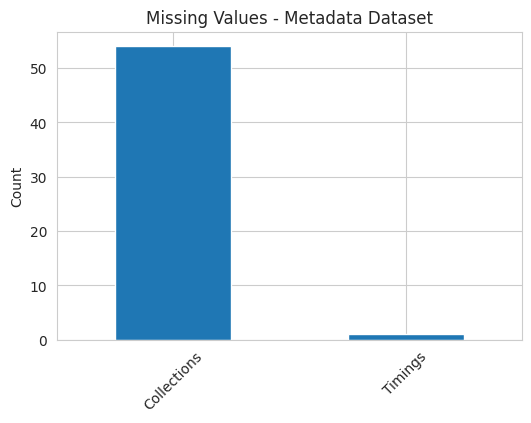

In [146]:
# Visualizing the missing values in metadata dataset
plt.figure(figsize=(6,4))
meta_null.plot(kind='bar')
plt.title("Missing Values - Metadata Dataset")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

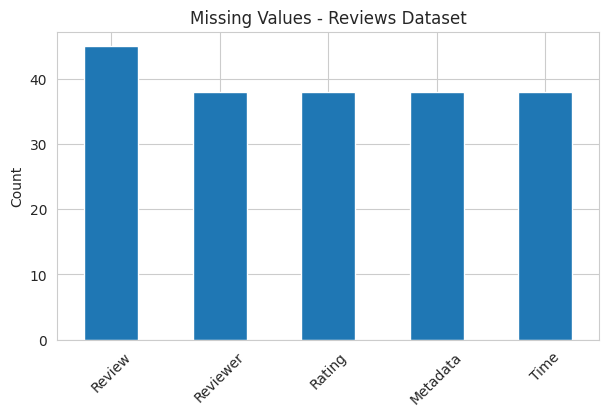

In [147]:
# Visualizing the missing values in reviews dataset
plt.figure(figsize=(7,4))
review_null.plot(kind='bar')
plt.title("Missing Values - Reviews Dataset")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

**Dataset Structure**

The project consists of two separate datasets:

**Metadata Dataset**

  *  Contains 105 restaurants

  *  6 columns: Name, Links, Cost, Collections, Cuisines, Timings

  *  All columns are stored as object (text) data type

**Reviews Dataset**

  *  Contains 10,000 customer reviews

  *  7 columns: Restaurant, Reviewer, Review, Rating, Metadata, Time, Pictures

  *  Most columns are object type

  *  Pictures column is numeric (int64)

----------
**Relationship Between Datasets**

  *  One restaurant (metadata) can have multiple reviews.

  *  Reviews dataset is significantly larger than metadata dataset.

  *  Both datasets can be connected using the restaurant name.  
  ---

**Data Quality Observations**

**Missing Values**

Metadata Dataset:
  
*  Collections column has more than 50% missing values.

*  Timings column has only 1 missing value.

Reviews Dataset:

*  Very small percentage (<1%) missing values in Reviewer, Review, Rating, Metadata, and Time columns.  

---
**Duplicate Records**

*  No duplicate rows found in metadata dataset.

*  36 duplicate rows identified in reviews dataset (not removed yet).

---

**Data Type Observations**

*  Cost column is stored as text and needs conversion to numeric.

*  Rating column is stored as text and needs cleaning before analysis.

*  Time column may require conversion to datetime format for further analysis.
---

**Overall Understanding**

*  The dataset is structured and mostly clean.

*  Reviews dataset provides rich textual data suitable for sentiment analysis.

*  Metadata dataset provides restaurant-level features useful for clustering.

*  Some preprocessing and cleaning will be required before modeling.

## ***2. Understanding Your Variables***

In [148]:
# Dataset Columns
metadata_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [149]:
# Dataset Describe
reviews_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

### Variables Description

**Metadata Dataset Variables**

| Variable Name | Description                                                        | Data Type |
| ------------- | ------------------------------------------------------------------ | --------- |
| Name          | Name of the restaurant                                             | Object    |
| Links         | URL link of the restaurant on Zomato                               | Object    |
| Cost          | Approximate cost for two people (stored as text, needs conversion) | Object    |
| Collections   | Category tags or special listings (e.g., trending, featured)       | Object    |
| Cuisines      | Types of cuisines offered by the restaurant                        | Object    |
| Timings       | Operating hours of the restaurant                                  | Object    |

**Reviews Dataset Variables**

| Variable Name | Description                                                   | Data Type |
| ------------- | ------------------------------------------------------------- | --------- |
| Restaurant    | Name of the restaurant being reviewed                         | Object    |
| Reviewer      | Name of the customer who gave the review                      | Object    |
| Review        | Text content of the customer review                           | Object    |
| Rating        | Rating given by the customer (stored as text, needs cleaning) | Object    |
| Metadata      | Additional review-related information                         | Object    |
| Time          | Timestamp of the review                                       | Object    |
| Pictures      | Number of pictures shared with the review                     | Integer   |



### Check Unique Values for each variable.

In [150]:
# Check Unique Values for each variable.
metadata_df.nunique()

,0
Name,105
Links,105
Cost,29
Collections,42
Cuisines,92
Timings,77


*  105 unique restaurants → matches total rows → no duplicates

*  Cost has 29 unique values → good variability

*  Cuisines has 92 unique values → very diverse dataset

*  High uniqueness in Timings → not useful for clustering

In [151]:
reviews_df.nunique()

,0
Restaurant,100
Reviewer,7446
Review,9364
Rating,10
Metadata,2477
Time,9782
Pictures,36


*  100 restaurants in reviews vs 105 in metadata
  → 5 restaurants may not have reviews

*  Rating has only 10 unique values
  → Likely 1–5 scale with decimals

*  Review text is highly unique → good for sentiment analysis

*  Reviewer count (7446) < total reviews (10000)
  → Some users posted multiple reviews

## 3. ***Data Wrangling***

### **MetaData Dataset Wrangling Code**

#### **Handle Missing Values**

In [152]:
# Checking percentage of missing values
meta_missing_percent = (metadata_df.isnull().sum() / len(metadata_df)) * 100
meta_missing_percent

,0
Name,0.000000
Links,0.000000
Cost,0.000000
Collections,51.428571
Cuisines,0.000000
Timings,0.952381


**Handling Missing Values in Collections Column**

In [153]:
metadata_df["Collections"] = metadata_df["Collections"].fillna("Not Specified")

**Check**

In [154]:
metadata_df["Collections"].isnull().sum()

np.int64(0)

**Handling Missing Values in Timings Column**

In [155]:
metadata_df = metadata_df.dropna(subset=["Timings"])

**Check**

In [156]:
metadata_df["Timings"].isnull().sum()

np.int64(0)

#### **Cleaning Cost column**

In [157]:
metadata_df["Cost"].head(10)

,Cost
0,800
1,800
2,"1,300"
3,800
4,"1,200"
5,"1,500"
6,500
7,300
8,"1,000"
9,350


In [158]:
# removing commas from Cost column
metadata_df["Cost"] = metadata_df["Cost"].str.replace(",", "")

# Converting Cost Column to Integer
metadata_df["Cost"] = metadata_df["Cost"].astype(int)

**Check**

In [159]:
metadata_df["Cost"].head()

,Cost
0,800
1,800
2,1300
3,800
4,1200


In [160]:
metadata_df["Cost"].dtype

dtype('int64')

#### **Detecting Outliers in Cost column**

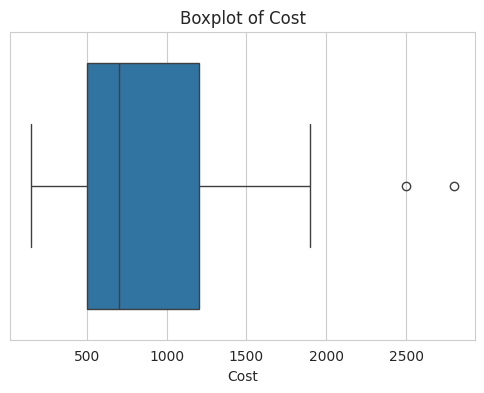

In [161]:
# Using Boxplot to visualy detect outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=metadata_df["Cost"])
plt.title("Boxplot of Cost")
plt.show()

In [162]:
#Using IQR method to calculate outliers mathematically.
Q1 = metadata_df["Cost"].quantile(0.25)
Q3 = metadata_df["Cost"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = metadata_df[(metadata_df["Cost"] < lower_bound) |
                       (metadata_df["Cost"] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.shape[0])
outliers[["Name","Cost"]]

Lower Bound: -550.0
Upper Bound: 2250.0
Number of Outliers: 2


,Name,Cost
56,Feast - Sheraton Hyderabad Hotel,2500
92,Collage - Hyatt Hyderabad Gachibowli,2800


#### **Standardize Column Names**

In [163]:
metadata_df.columns = (
    metadata_df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

metadata_df.columns

Index(['name', 'links', 'cost', 'collections', 'cuisines', 'timings'], dtype='object')

**Check**

In [164]:
metadata_df.columns

Index(['name', 'links', 'cost', 'collections', 'cuisines', 'timings'], dtype='object')

#### **Remove Extra Space in Cuisines column**

In [165]:
metadata_df['cuisines']

,cuisines
0,"Chinese, Continental, Kebab, European, South I..."
1,"Biryani, North Indian, Chinese"
2,"Asian, Mediterranean, North Indian, Desserts"
3,"Biryani, North Indian, Chinese, Seafood, Bever..."
4,"Asian, Continental, North Indian, Chinese, Med..."
...,...
100,"Fast Food, Salad"
101,"Bakery, Mithai"
102,"North Indian, Biryani, Chinese"
103,Fast Food


In [166]:
metadata_df["cuisines"] = (
    metadata_df["cuisines"]
    .str.strip()
    .str.replace(", ", ",")
)

### **Review Dataset Wrangling Code**

#### **Standardize Column Names**

In [167]:
reviews_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [168]:
#standardizing all the columns in review_df dataset
reviews_df.columns = (
    reviews_df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

**Check**

In [169]:
#checking after standardization of review_df dataset
reviews_df.columns

Index(['restaurant', 'reviewer', 'review', 'rating', 'metadata', 'time',
       'pictures'],
      dtype='object')

#### **Handling Missing Rows**

Missing rows in **review column**

In [170]:
# check missing values in review column
reviews_df[reviews_df["review"].isnull()].head()

,restaurant,reviewer,review,rating,metadata,time,pictures
2360,Amul,Lakshmi Narayana,NaN,5,0 Reviews,7/29/2018 18:00,0
5799,Being Hungry,Surya,NaN,5,"4 Reviews , 4 Followers",7/19/2018 23:55,0
6449,Hyderabad Chefs,Madhurimanne97,NaN,5,1 Review,7/23/2018 16:29,0
6489,Hyderabad Chefs,Harsha,NaN,5,1 Review,7/8/2018 21:19,0
7954,Olive Garden,ARUGULLA PRAVEEN KUMAR,NaN,3,"1 Review , 1 Follower",8/9/2018 23:25,0


Missing rows in **rating column**

In [171]:
# check missing rows in rating column
reviews_df[reviews_df["rating"].isnull()].head()

,restaurant,reviewer,review,rating,metadata,time,pictures
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8781,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0


Drop rows where **rating** is null in **rating column**

In [172]:
#droping the rows from the rating column where the values are null
reviews_df = reviews_df.dropna(subset=["rating"])

**Check Shape**

In [173]:
# After droping null values checking the shape of reviews_df dataset
reviews_df.shape

(9962, 7)

In [174]:
# check null values in review column after droping null values from rating column
reviews_df["review"].isnull().sum()

np.int64(7)

Drop 7 rows in the **review column**

In [175]:
# droping the rows of review column having null values
reviews_df = reviews_df.dropna(subset=["review"])

**Check Shape**

In [176]:
#c checking the shape of review_df dataset
reviews_df.shape

(9955, 7)

#### **Clean the rating Column**

In [177]:
# insepcting unqiue values in rating column
reviews_df["rating"].unique()

array(['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5', 'Like'],
      dtype=object)

In [178]:
#checking the no of rows having "Like" in rating column
(reviews_df["rating"] == "Like").sum()

np.int64(1)

In [179]:
# removing the row having "like" value in rating column
reviews_df = reviews_df[reviews_df["rating"] != "Like"]

reviews_df["rating"].unique()

array(['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5'], dtype=object)

#### **Convert rating Column to Float**

In [180]:
# converting the rating column from string to float
reviews_df["rating"] = reviews_df["rating"].astype(float)

reviews_df["rating"].dtype

dtype('float64')

#### **Convert time Column to Datetime**

In [181]:
# Convert 'time' column from object (string) to datetime format
# errors='coerce' ensures that any invalid format becomes NaT instead of breaking the code
reviews_df["time"] = pd.to_datetime(reviews_df["time"], errors="coerce")

# Check the datatype after conversion
reviews_df["time"].dtype

dtype('<M8[ns]')

In [182]:
# Check if any values became NaT (invalid datetime)
reviews_df["time"].isnull().sum()

np.int64(0)

#### **Dropping Irrelevant Column**

In [183]:
# View first 10 values of metadata column
reviews_df["metadata"].head(10)

,metadata
0,"1 Review , 2 Followers"
1,"3 Reviews , 2 Followers"
2,"2 Reviews , 3 Followers"
3,"1 Review , 1 Follower"
4,"3 Reviews , 2 Followers"
5,1 Review
6,1 Review
7,1 Review
8,"1 Review , 1 Follower"
9,"1 Review , 1 Follower"


In [184]:
# Check some unique values
reviews_df["metadata"].unique()[:10]

array(['1 Review , 2 Followers', '3 Reviews , 2 Followers',
       '2 Reviews , 3 Followers', '1 Review , 1 Follower', '1 Review',
       '3 Reviews , 1 Follower', '2 Reviews , 25 Followers',
       '4 Reviews , 7 Followers', '30 Reviews , 34 Followers',
       '6 Reviews , 267 Followers'], dtype=object)

In [185]:
# Check if any missing values exist in metadata
reviews_df["metadata"].isnull().sum()

np.int64(0)

In [186]:
# Drop reviewer metadata column (not relevant for restaurant clustering)
reviews_df = reviews_df.drop(columns=["metadata"])

# Drop 'reviewer' column as it is not relevant for restaurant clustering
reviews_df = reviews_df.drop(columns=["reviewer"])

# Drop 'pictures' column as it represents reviewer behavior,
# not restaurant characteristics
reviews_df = reviews_df.drop(columns=["pictures"])

In [187]:
#Check
reviews_df.columns

Index(['restaurant', 'review', 'rating', 'time'], dtype='object')

### **Merging Datasets (MetaData + Reviews) and then applying Wrangling**

In [188]:
metadata_df.columns

Index(['name', 'links', 'cost', 'collections', 'cuisines', 'timings'], dtype='object')

In [189]:
reviews_df.columns

Index(['restaurant', 'review', 'rating', 'time'], dtype='object')

In [190]:
# Check whether all review restaurants exist in metadata
set(reviews_df["restaurant"]).issubset(set(metadata_df["name"]))

False

In [191]:
# Merge metadata and reviews dataset
# Left join ensures we keep all review records
# Matching is done between:
#   metadata_df.name  ↔  reviews_df.restaurant

merged_df = pd.merge(
    reviews_df,
    metadata_df,
    left_on="restaurant",
    right_on="name",
    how="left"
)

# Check shape after merge
merged_df.shape

(9954, 10)

In [192]:
# Drop duplicate 'name' column (same as restaurant)
merged_df = merged_df.drop(columns=["name"])

# Confirm final columns
merged_df.columns

Index(['restaurant', 'review', 'rating', 'time', 'links', 'cost',
       'collections', 'cuisines', 'timings'],
      dtype='object')

#### **Droping irrelevant columns**

In [193]:
# Drop 'links' column (URL identifier - not useful for analysis)
# Drop 'timings' column (complex text feature - not relevant for clustering)
merged_df = merged_df.drop(columns=["links", "timings"])

# Confirm updated columns after removal
merged_df.columns

Index(['restaurant', 'review', 'rating', 'time', 'cost', 'collections',
       'cuisines'],
      dtype='object')

### What all manipulations have you done and insights you found?

**Metadata Wrangling**

*  Filled missing values in collections

*  Dropped 1 row with missing timings

*  Cleaned cost column (removed commas, converted to int)

*  Checked and retained valid outliers

*  Standardized column names

*  Cleaned cuisines formatting.

----

**Reviews Wrangling**

*  Dropped rows with null ratings

*  Dropped rows with null reviews

*  Removed 1 “Like” rating

*  Converted rating to float

*  Removed duplicates

*  Converted time to datetime

*  Dropped irrelevant columns:

    * reviewer

    * metadata

    * pictures

----

**Merging**

*  Verified restaurant matching

*  Performed left merge

*  Dropped duplicate name column

*  Dropped timing and links column

*  Final merged shape: (9954, 7)

In [194]:
# ==========================================
# Save Cleaned & Merged Dataset
# ==========================================

merged_df.to_csv("/content/Machine-Learning-Portfolio/03_ML_Practice/Zomato_Restaurant_Clustering/processed_data/zomato_cleaned_merged.csv", index=False)

print("File saved successfully!")

File saved successfully!


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Univariate Analysis**


#### **Chart - 1 Rating Distribution**

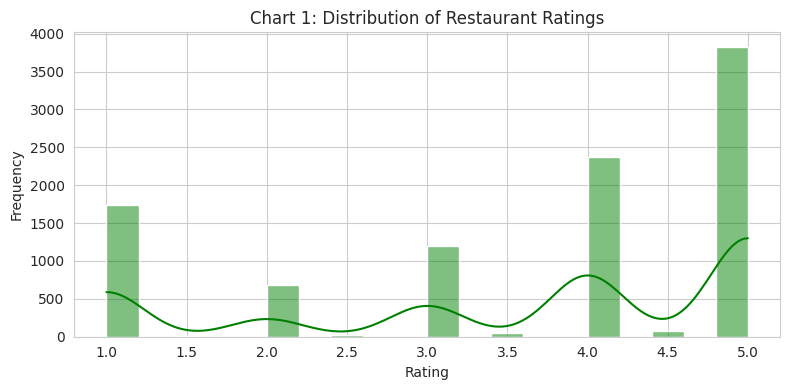

In [195]:
# ==========================================
# Chart 1: Distribution of Ratings
# ==========================================

plt.figure(figsize=(8,4))

sns.histplot(data=merged_df,
             x='rating',
             bins=20,
             kde=True,
             color = 'green')

plt.title("Chart 1: Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To understand the overall distribution of customer satisfaction.

*  To check whether ratings are normally distributed, skewed, or concentrated.

*  To verify if rating has enough variance for clustering.

*  Histogram + KDE helps visualize both frequency and density trend.

*  Rating will be one of the strongest clustering features → must understand its behavior first.

##### 2. What is/are the insight(s) found from the chart?

*  Ratings are heavily concentrated between 4.0 and 5.0.

*  Very high spike at 5.0 rating.

*  Very few restaurants have ratings between 2.5 – 3.5.

*  Noticeable count at 1.0 rating (indicating strongly dissatisfied customers).

*  Distribution is right-skewed toward high ratings.

*  Rating appears discrete rather than continuous (clear spikes at integers).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Signals**

*  Majority of restaurants are rated highly → platform quality perception is strong.

*  Strong high-rating cluster means Zomato brand trust is high.

*  High rating dominance may attract new users and increase retention.

---

**Potential Negative Signals**

*  Presence of many 1-star ratings indicates:

*  Service quality inconsistency.

*  Possible hygiene / delivery / food quality issues.

*  If too many restaurants have 5.0 ratings:

*  Possible rating inflation.

*  Reduced differentiation between good and excellent restaurants.

*  Clustering might form large “High Rating” cluster with weak separation.

#### **Chart - 2 Distribution of Restaurant Cost**

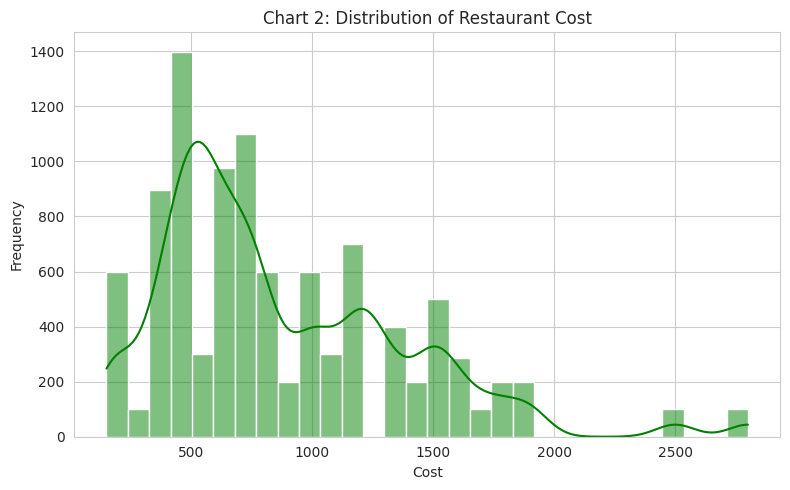

In [196]:
# ==========================================
# Chart 2: Distribution of Restaurant Cost
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(data=merged_df,
             x='cost',
             bins=30,
             kde=True,
             color = 'green')

plt.title("Chart 2: Distribution of Restaurant Cost")
plt.xlabel("Cost")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  Cost is a primary segmentation feature in restaurant clustering.

*  To understand price spread across restaurants.

*  To detect skewness and long-tail distribution.

*  To identify premium outliers.

*  To decide whether scaling or log transformation is needed before ML.

*  Histogram + KDE helps visualize density concentration and tail behavior.

##### 2. What is/are the insight(s) found from the chart?

*  Distribution is right-skewed (long tail toward high cost).

*  Majority of restaurants fall in the ₹400–₹1000 range.

*  Clear density peak around ₹500–₹700.

*  Very few restaurants exist beyond ₹2000+.

*  Premium restaurants (₹2500–₹2800) form a small niche segment.

*  Cost variance is high → good for clustering separation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Signals**

*  Platform has strong presence in affordable & mid-range segment.

*  Wide cost variation allows:

    * Budget cluster

    * Mid-range cluster

    * Premium cluster

*  Enables targeted marketing campaigns:

    * Student segment (low cost)

    * Family dining (mid-range)

    *  Luxury dining (premium)

---
**Potential Negative Signals**

*  Heavy concentration in mid-range → high competition.

*  Premium restaurants are very few → revenue from luxury segment may be limited.

*  Right-skewness means:

    *  Clustering may get biased if scaling is not applied.

    *  High-cost restaurants could distort centroid positions.

#### **Chart - 3 Distribution of Review Length**

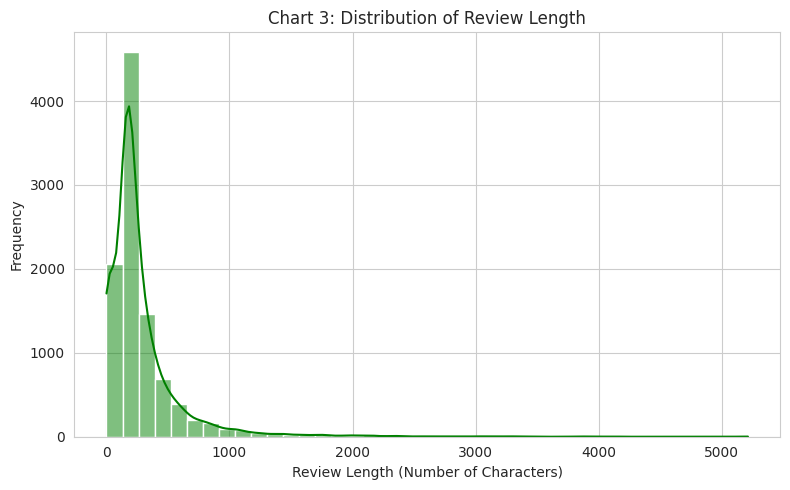

In [197]:
# ==========================================
# Chart 3: Distribution of Review Length
# ==========================================

# Create review length feature
merged_df['review_length'] = merged_df['review'].str.len()

plt.figure(figsize=(8,5))

sns.histplot(data=merged_df,
             x='review_length',
             bins=40,
             kde=True,
             color = 'green')

plt.title("Chart 3: Distribution of Review Length")
plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To understand customer engagement depth (short vs detailed reviews).

*  To verify if text data is rich enough for sentiment modeling.

*  Review length can act as a clustering feature (emotional intensity indicator).

##### 2. What is/are the insight(s) found from the chart?

*  Distribution is heavily right-skewed (many short reviews, few long ones).

*  Majority of reviews are under 400–500 characters.

*  Presence of extreme long reviews (2000+ characters) → strong opinion cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Short reviews suggest quick feedback culture → high platform activity.

*  Long reviews may indicate strong satisfaction/dissatisfaction → useful for sentiment-based clustering.

*  Skewness means scaling may be required if used in clustering to avoid dominance by extreme values.

#### **Chart - 4 Top Cuisines Distribution**

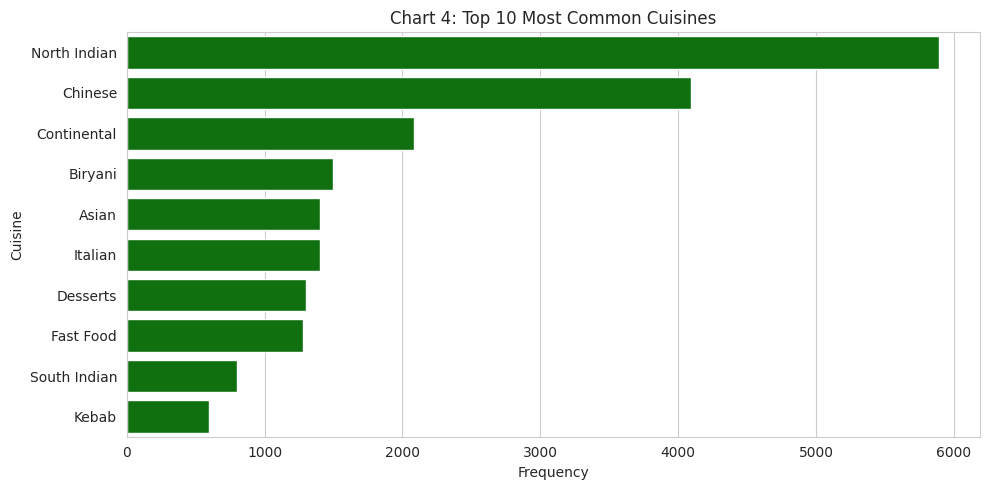

In [198]:
# ==========================================
# Chart 4: Top 10 Most Common Cuisines
# ==========================================

# Split cuisines if multiple cuisines are comma separated
cuisine_series = merged_df['cuisines'].str.split(',').explode().str.strip()

top_cuisines = cuisine_series.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_cuisines.values,
            y=top_cuisines.index,color='green')

plt.title("Chart 4: Top 10 Most Common Cuisines")
plt.xlabel("Frequency")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  Cuisine is a strong categorical driver for restaurant segmentation.

*  To understand market dominance and concentration.

*  Helps identify cuisine-based clustering potential.

##### 2. What is/are the insight(s) found from the chart?

*  North Indian dominates significantly (clear market leader).

*  Chinese is second strongest category.

*  Remaining cuisines have relatively balanced mid-level presence.

*  Market is concentrated around few dominant cuisines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  High dominance of North Indian → intense competition in that segment.

*  Opportunity to differentiate via niche cuisines (e.g., Kebab, South Indian).

*  Cuisine-based clustering can help targeted promotions and category optimization.

#### **Chart - 5 Top 10 Collections**

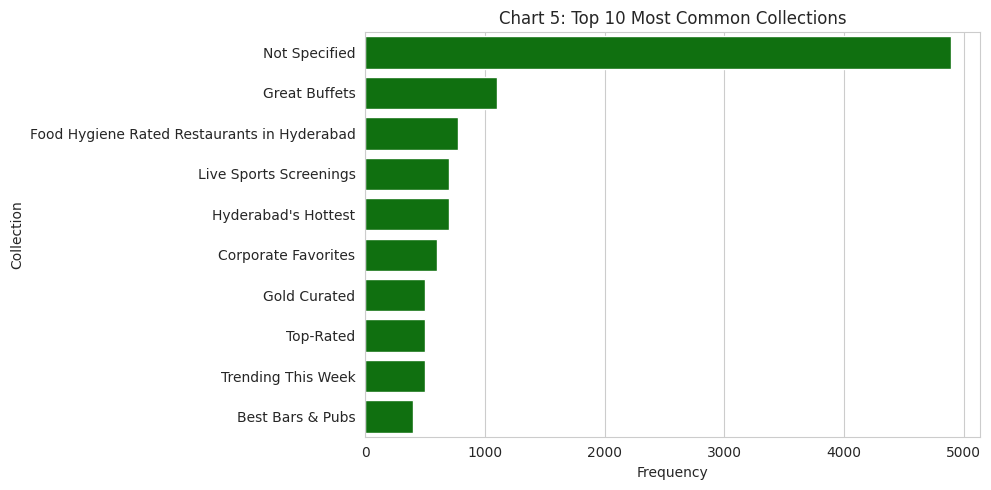

In [199]:
# ==========================================
# Chart 5: Top 10 Most Common Collections
# ==========================================

collection_series = merged_df['collections'].str.split(',').explode().str.strip()

top_collections = collection_series.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_collections.values,
            y=top_collections.index,
            color='green')

plt.title("Chart 5: Top 10 Most Common Collections")
plt.xlabel("Frequency")
plt.ylabel("Collection")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  Collections represent marketing positioning of restaurants.

*  Helps identify dominant promotional themes on the platform.

*  Useful for behavioral clustering (e.g., Buffet cluster, Sports cluster).

##### 2. What is/are the insight(s) found from the chart?

*  “Not Specified” dominates heavily → many restaurants lack collection tagging.

*  “Great Buffets” is the strongest defined collection.

*  Event-based and lifestyle collections (Live Sports, Corporate, Bars) have moderate presence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Large “Not Specified” share suggests underutilized tagging → opportunity for better curation.

*  Buffet & Top-Rated collections can be segmented for premium campaigns.

*  Better collection tagging could improve personalization & recommendation systems.

#### **Chart - 6 Monthly Review Volume Trend**

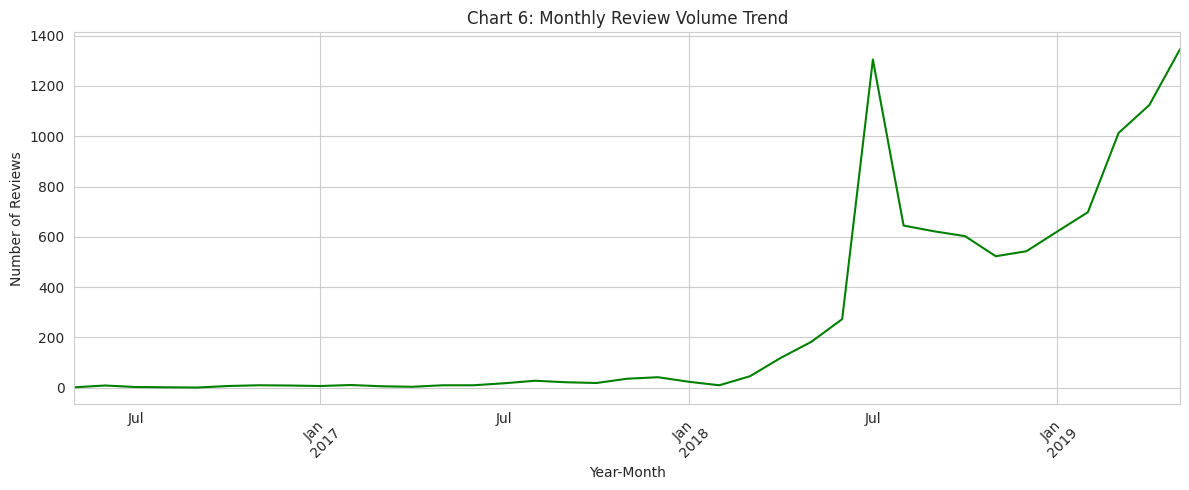

In [200]:
# ==========================================
# Chart 6: Monthly Review Trend
# ==========================================

# Create year-month column
merged_df['year_month'] = merged_df['time'].dt.to_period('M')

monthly_reviews = merged_df.groupby('year_month').size()

plt.figure(figsize=(12,5))

monthly_reviews.plot(color='green')

plt.title("Chart 6: Monthly Review Volume Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To analyze platform engagement growth over time.

*  To detect seasonal spikes or sudden anomalies.

*  Time trend helps understand dynamic customer behavior for future segmentation.

##### 2. What is/are the insight(s) found from the chart?

*  Reviews were very low initially, then sharply increased around mid-2018.

*  Significant spike indicates sudden growth phase or data onboarding event.

*  After spike, reviews stabilize at a much higher level than earlier years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Sharp growth suggests strong user acquisition or market expansion.

*  Sudden spike may indicate marketing campaign, expansion, or dataset anomaly (needs validation).

*  Increasing review volume strengthens reliability of clustering & sentiment analysis.

### **Bivariate Analysis**

#### **Numeric vs Numeric**

#### **Chart - 7 Cost vs Rating**

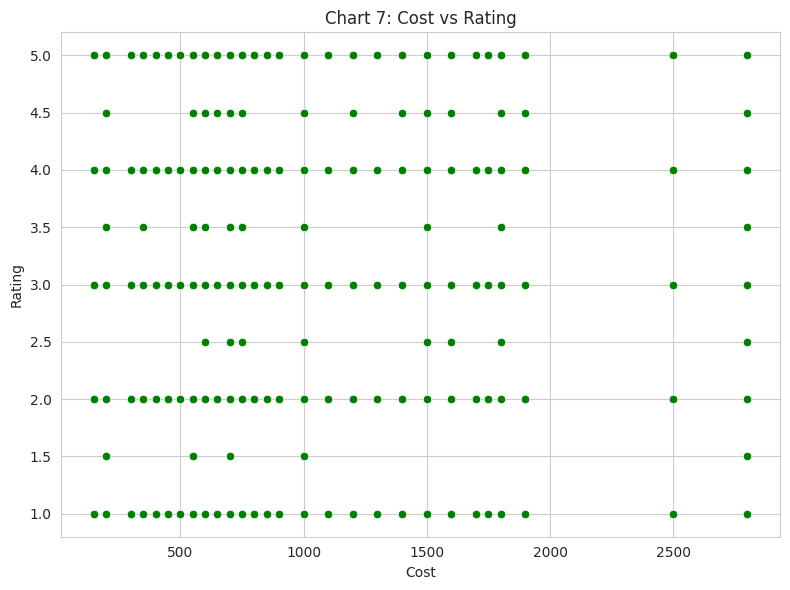

In [201]:
# ==========================================
# Chart 7: Cost vs Rating
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(data=merged_df,
                x='cost',
                y='rating',
                color='green')

plt.title("Chart 7: Cost vs Rating")
plt.xlabel("Cost")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To evaluate whether pricing influences customer satisfaction.

*  Cost and rating are primary numeric drivers for clustering.

*  Helps detect correlation strength before applying ML algorithms.

##### 2. What is/are the insight(s) found from the chart?

*  Ratings are spread across all cost ranges → no strong linear relationship.

*  High-cost restaurants do not consistently guarantee higher ratings.

*  Rating appears discrete (horizontal lines), indicating ordinal nature.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Pricing alone cannot justify premium positioning — service/quality matters more.

*  Clusters may form as “High Cost + Low Rating” and “Low Cost + High Rating” segments.

*  Weak correlation suggests cost and rating should both be retained independently in clustering.

#### **Chart - 8 Review Length vs Rating**

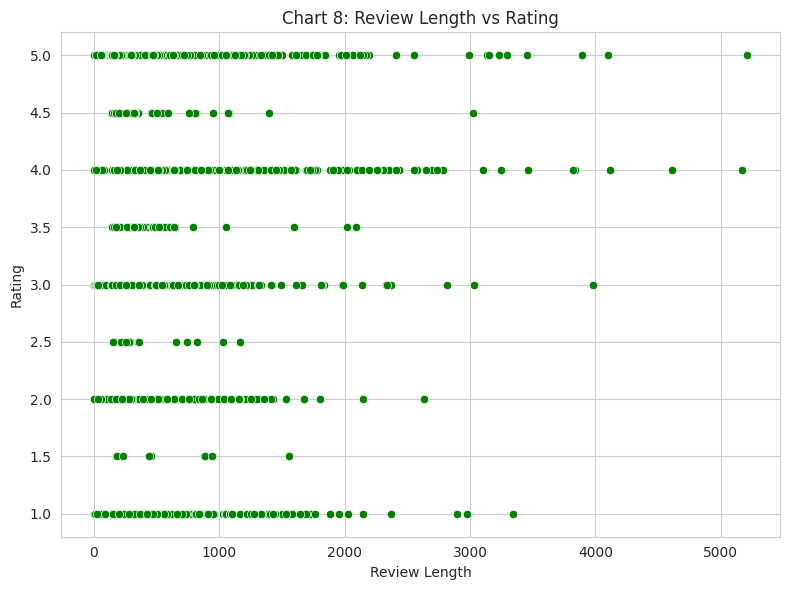

In [202]:
# ==========================================
# Chart 8: Review Length vs Rating
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(data=merged_df,
                x='review_length',
                y='rating',
                color='green')

plt.title("Chart 8: Review Length vs Rating")
plt.xlabel("Review Length")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To examine whether emotional intensity (longer reviews) relates to rating polarity.

*  Review length may serve as a behavioral clustering feature.

*  Helps validate sentiment-analysis usefulness.

##### 2. What is/are the insight(s) found from the chart?

*  Longer reviews appear across both very low (1⭐) and very high (5⭐) ratings.

*  Mid ratings (3⭐–4⭐) generally have moderate-length reviews.

*  No strong linear correlation, but extreme ratings tend to have longer text.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Strong emotions (positive or negative) drive longer feedback.

*  Long negative reviews may highlight service gaps → quality improvement opportunity.

*  Review length can help segment “Highly Engaged Customers” vs “Casual Reviewers.”

#### **Categorical vs Numeric**

#### **Chart - 9 Top 10 Cuisines vs Average Rating**

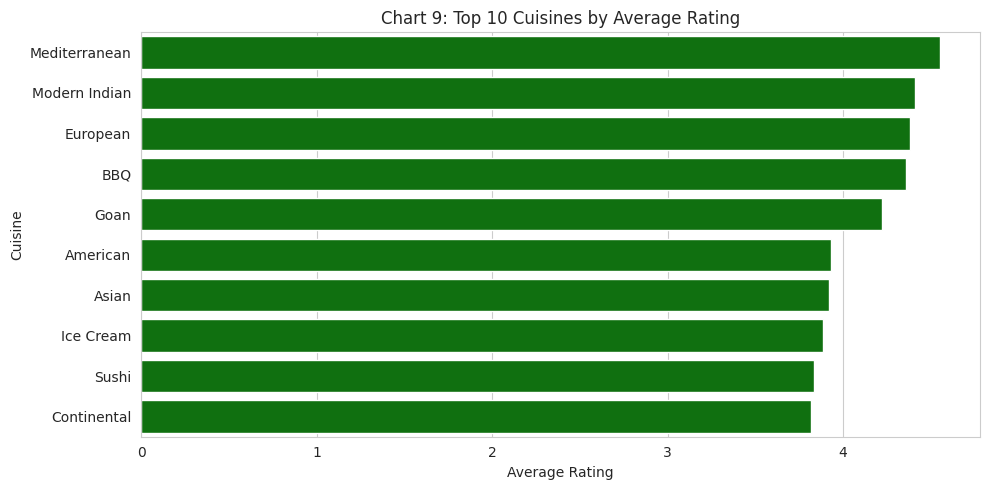

In [203]:
# ==========================================
# Chart 9: Top 10 Cuisines vs Average Rating
# ==========================================

# Explode cuisines
cuisine_df = merged_df.copy()
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.split(',')
cuisine_df = cuisine_df.explode('cuisines')
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.strip()

# Compute average rating
avg_rating_cuisine = (
    cuisine_df.groupby('cuisines')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(x=avg_rating_cuisine.values,
            y=avg_rating_cuisine.index,
            color='green')

plt.title("Chart 9: Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To evaluate cuisine-wise customer satisfaction performance.

*  Cuisine may explain rating differences in clustering.

*  Helps identify premium vs standard performing cuisine segments.

##### 2. What is/are the insight(s) found from the chart?

*  Mediterranean has the highest average rating.

*  Modern Indian, European, and BBQ also show strong performance (>4.3 approx).

*  Even the lowest in top 10 (Continental) maintains relatively high ratings (~3.8+).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  High-rated cuisines can be positioned as premium recommendation clusters.

*  Opportunity to promote high-performing cuisines more aggressively.

*  If dominant cuisines (from frequency chart) are not top-rated → quality improvement opportunity.

#### **Chart - 10 Top Collections vs Average Rating**

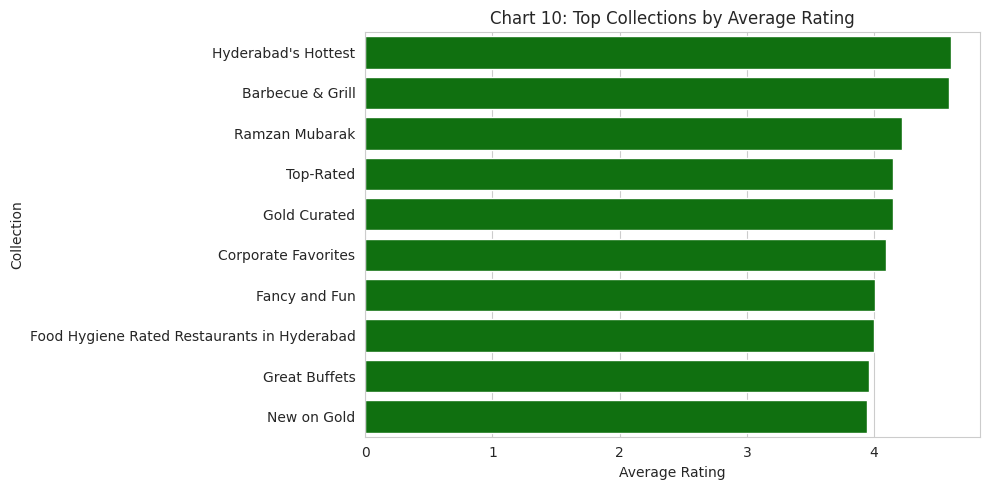

In [204]:
# ==========================================
# Chart 10: Top Collections vs Average Rating
# ==========================================

collection_df = merged_df.copy()
collection_df['collections'] = collection_df['collections'].str.split(',')
collection_df = collection_df.explode('collections')
collection_df['collections'] = collection_df['collections'].str.strip()

avg_rating_collection = (
    collection_df.groupby('collections')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(x=avg_rating_collection.values,
            y=avg_rating_collection.index,
            color='green')

plt.title("Chart 10: Top Collections by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Collection")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To evaluate performance of curated restaurant collections.

*  To check whether marketing tags align with customer satisfaction.

*  Useful for behavioral and thematic clustering.

##### 2. What is/are the insight(s) found from the chart?

*  “Hyderabad’s Hottest” and “Barbecue & Grill” show the highest average ratings.

*  Most top collections maintain ratings above ~4.0.

*  Collections labeled “Top-Rated” and “Gold Curated” genuinely perform well.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Marketing curation appears aligned with customer satisfaction (positive signal).

*  High-performing collections can be promoted more aggressively.

*  Reliable collection tags improve recommendation system accuracy.

#### **Categorical vs Numeric**

#### **Chart - 11 Top 10 Cuisines vs Average Cost**

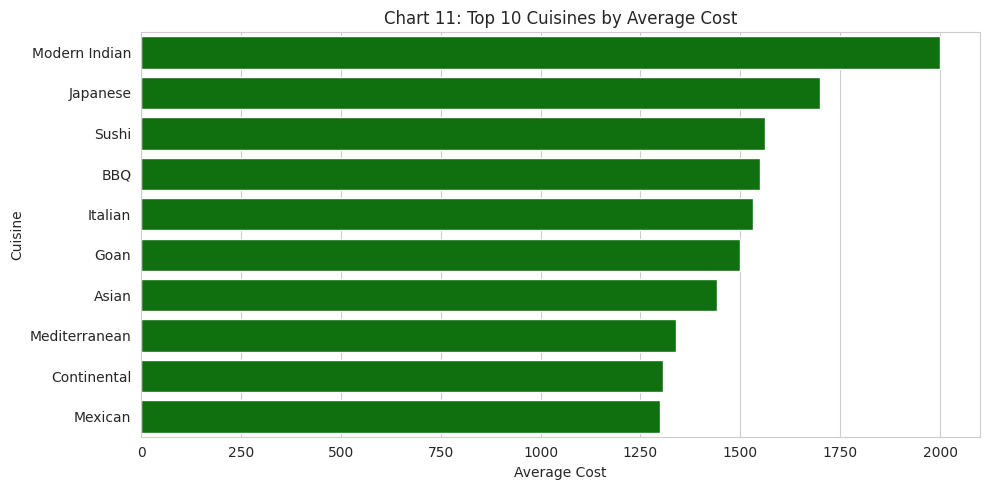

In [205]:
# ==========================================
# Chart 11: Top 10 Cuisines vs Average Cost
# ==========================================

avg_cost_cuisine = (
    cuisine_df.groupby('cuisines')['cost']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(x=avg_cost_cuisine.values,
            y=avg_cost_cuisine.index,
            color='green')

plt.title("Chart 11: Top 10 Cuisines by Average Cost")
plt.xlabel("Average Cost")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To identify premium vs budget cuisine segments.

*  Pricing + cuisine combination is powerful for clustering.

*  Helps detect luxury and mid-range positioning.

##### 2. What is/are the insight(s) found from the chart?

*  Modern Indian is the most expensive cuisine.

*  Japanese and Sushi also fall in premium pricing tier.

*  Continental and Mexican are relatively lower within top 10 premium group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Premium cuisine cluster clearly exists (Modern Indian, Japanese, Sushi).

*  Pricing-based segmentation can support luxury targeting strategies.

*  If high-cost cuisines don’t align with highest ratings → potential value mismatch risk.

#### **Categorical vs Categorical**

#### **Chart - 12 Cuisine vs Collection**

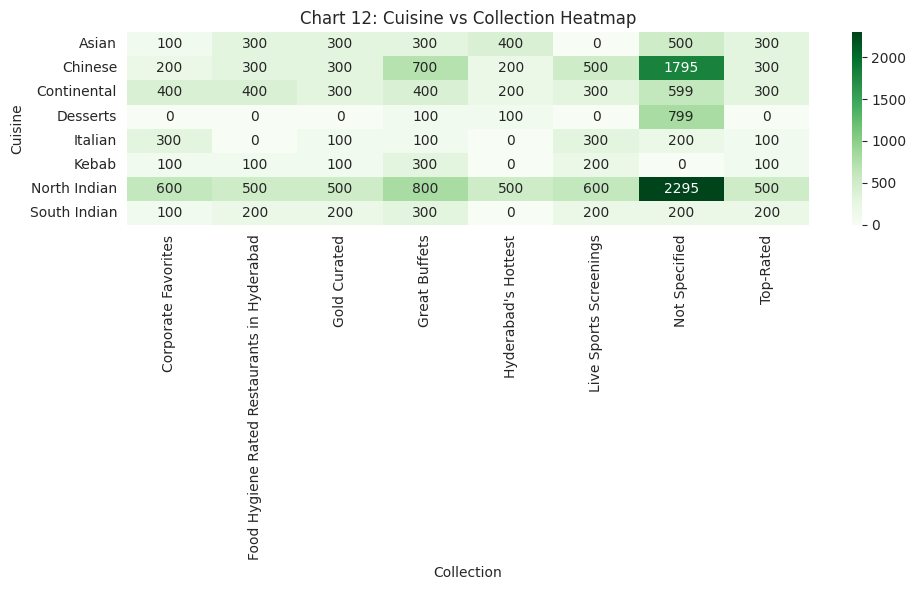

In [206]:
# ==========================================
# Chart 12: Cuisine vs Collection Heatmap
# ==========================================

# Prepare exploded dataframe
cc_df = merged_df.copy()

cc_df['cuisines'] = cc_df['cuisines'].str.split(',')
cc_df = cc_df.explode('cuisines')
cc_df['cuisines'] = cc_df['cuisines'].str.strip()

cc_df['collections'] = cc_df['collections'].str.split(',')
cc_df = cc_df.explode('collections')
cc_df['collections'] = cc_df['collections'].str.strip()

# Select top 8 cuisines & collections for clarity
top_cuisines = cc_df['cuisines'].value_counts().head(8).index
top_collections = cc_df['collections'].value_counts().head(8).index

filtered_df = cc_df[
    (cc_df['cuisines'].isin(top_cuisines)) &
    (cc_df['collections'].isin(top_collections))
]

# Create pivot table
pivot_table = pd.crosstab(filtered_df['cuisines'],
                          filtered_df['collections'])

plt.figure(figsize=(10,6))

sns.heatmap(pivot_table,
            cmap="Greens",
            annot=True,
            fmt='d')

plt.title("Chart 12: Cuisine vs Collection Heatmap")
plt.xlabel("Collection")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To understand overlap between cuisine categories and marketing collections.

*  Helps detect dominant thematic groupings.

*  Useful for identifying multi-dimensional clusters (Cuisine + Theme).

##### 2. What is/are the insight(s) found from the chart?

*  North Indian dominates across multiple collections, especially “Not Specified.”

*  Chinese strongly appears in “Not Specified” and “Great Buffets.”

*  Some cuisines (e.g., Desserts, Kebab) have limited presence across collections.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Heavy dominance of North Indian indicates high competition within that segment.

*  Large “Not Specified” overlap shows missed curation opportunity.

*  Cuisine-collection combinations can form strong marketing-driven clusters.

### **Multivariate Analysis**

#### **Chart - 13 Cost vs Rating vs Cuisine**

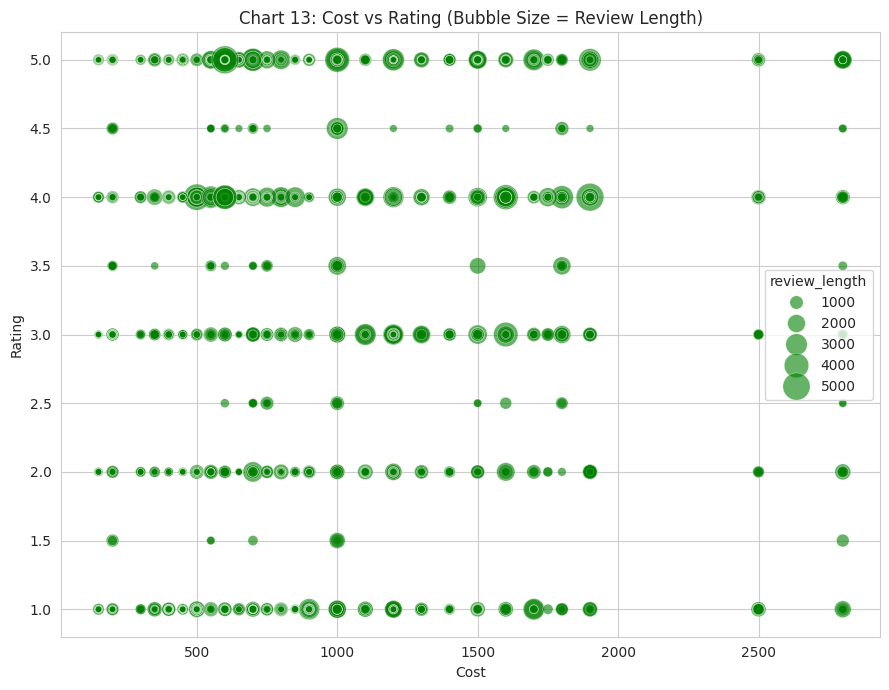

In [207]:
# ==========================================
# Chart 13: Cost vs Rating vs Review Length
# ==========================================

plt.figure(figsize=(9,7))

sns.scatterplot(data=merged_df,
                x='cost',
                y='rating',
                size='review_length',
                sizes=(20, 400),
                color='green',
                alpha=0.6)

plt.title("Chart 13: Cost vs Rating (Bubble Size = Review Length)")
plt.xlabel("Cost")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To analyze 3 variables simultaneously (Cost, Rating, Engagement).

*  To detect natural cluster groupings visually.

*  Helps validate whether engagement differs across price-rating segments.

##### 2. What is/are the insight(s) found from the chart?

*  Large bubbles (long reviews) appear mostly at extreme ratings (1⭐ & 5⭐).

*  High-cost restaurants are spread across all rating levels.

*  Mid-cost range (~500–1500) shows dense concentration → likely major cluster zone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Strong emotional engagement occurs at both high satisfaction and dissatisfaction.

*  Premium pricing does not guarantee better ratings or engagement.

*  Clear segmentation zones exist → supports clustering feasibility.

#### **Chart - 14 Monthly Trend – Rating & Cost Behavior Over Time**

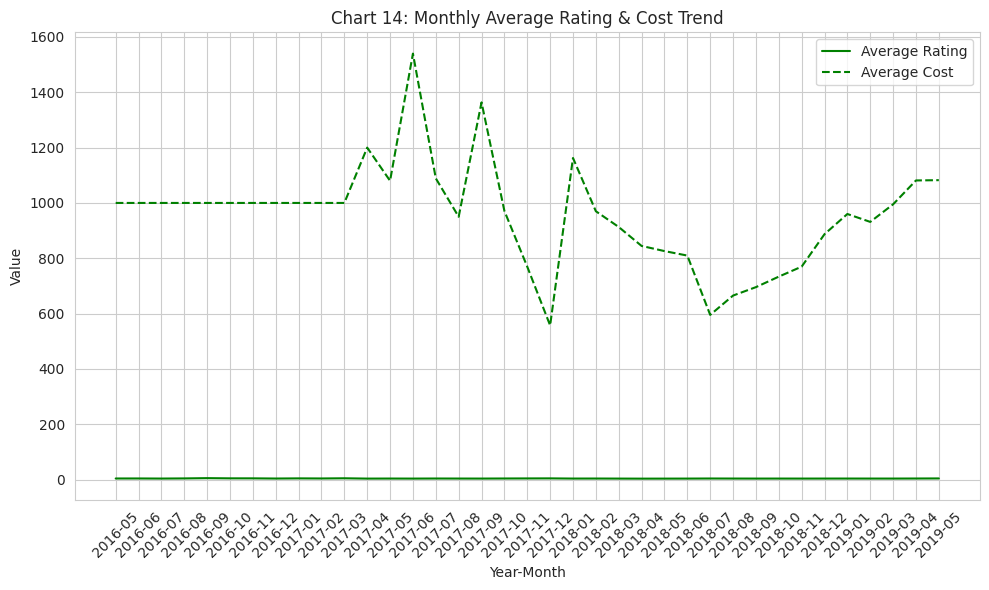

In [208]:
# ==========================================
# Chart 14: Monthly Average Rating & Cost Trend
# ==========================================

monthly_trend = merged_df.groupby('year_month').agg({
    'rating': 'mean',
    'cost': 'mean'
}).reset_index()

plt.figure(figsize=(10,6))

plt.plot(monthly_trend['year_month'].astype(str),
         monthly_trend['rating'],
         color='green',
         label='Average Rating')

plt.plot(monthly_trend['year_month'].astype(str),
         monthly_trend['cost'],
         color='green',
         linestyle='--',
         label='Average Cost')

plt.xticks(rotation=45)

plt.title("Chart 14: Monthly Average Rating & Cost Trend")
plt.xlabel("Year-Month")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To analyze whether pricing and satisfaction change over time.

*  To detect temporal instability before clustering.

*  To check if time-based segmentation is necessary.

##### 2. What is/are the insight(s) found from the chart?

*  Average rating remains relatively stable over time.

*  Average cost shows noticeable fluctuations across months.

*  No strong synchronized movement between rating and cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Stable ratings indicate consistent service quality over time.

*  Cost fluctuations may reflect seasonal pricing or premium launches.

*  Since rating is stable, clustering does not need time-weighted adjustment.

#### **Chart - 15  Correlation Heatmap**

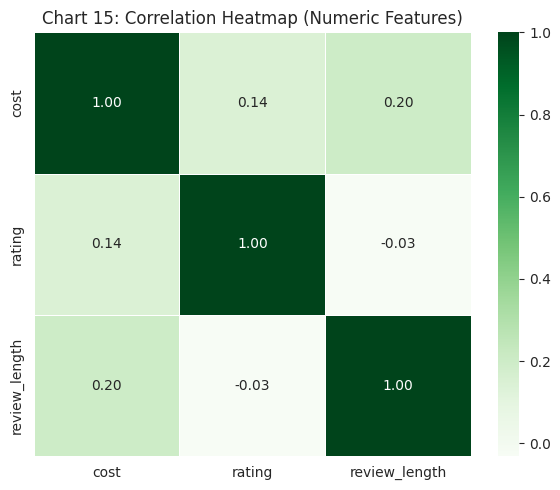

In [209]:
# ==========================================
# Chart 15: Correlation Heatmap
# ==========================================

# Select numeric features
numeric_df = merged_df[['cost', 'rating', 'review_length']]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="Greens",
            fmt=".2f",
            linewidths=0.5)

plt.title("Chart 15: Correlation Heatmap (Numeric Features)")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To quantify relationships between numeric features.

*  Clustering works best when features are not strongly correlated.

*  Helps justify feature selection before scaling & K-Means.

##### 2. What is/are the insight(s) found from the chart?

*  Cost vs Rating → very weak positive correlation (0.14).

*  Cost vs Review Length → weak correlation (0.20).

*  Rating vs Review Length → almost no correlation (-0.03).

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### **Hypothetical Statement - 1 Higher cost restaurants have significantly higher ratings.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

🔹 **Null Hypothesis (H₀):**

There is no significant linear relationship between restaurant cost and rating.

(H₀) :ρ=0

🔹 **Alternative Hypothesis (H₁):**

There is a significant linear relationship between restaurant cost and rating.

H₁:𝜌≠0


Where ρ represents the population correlation coefficient.

#### 2. Perform an appropriate statistical test.

In [210]:
# Perform Statistical Test to obtain P-Value
# ==========================================
# Clean Data Before Correlation Test
# ==========================================


# Drop missing values
clean_df = merged_df[['cost', 'rating']].dropna()

correlation, p_value = pearsonr(clean_df['cost'], clean_df['rating'])

print("Correlation Coefficient (r):", round(correlation, 3))
print("P-value:", p_value)

Correlation Coefficient (r): 0.145
P-value: 2.33960493370531e-47


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test



##### Why did you choose the specific statistical test?

Both variables (cost & rating) are numeric.

We are testing linear association.

Pearson measures strength + significance of correlation.

Statistical Decision

Since p-value < 0.05,
We reject the Null Hypothesis (H₀).

There is a statistically significant relationship between cost and rating.

Although statistically significant:

Correlation = 0.145

This indicates a very weak positive relationship

Why p-value is extremely small?
Because:

Sample size ≈ 10,000 (very large)

Even small effects become statistically significant

### **Hypothetical Statement - 2 Premium cuisines have significantly higher average cost than non-premium cuisines.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant difference in average cost between premium and non-premium cuisines.
	​
  
  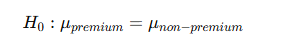


🔹 Alternative Hypothesis (H₁):

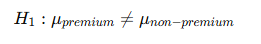

Premium cuisines have a significantly different (higher) average cost than non-premium cuisines.


#### 2. Perform an appropriate statistical test.

In [211]:
# Perform Statistical Test to obtain P-Value
# ==========================================
# Hypothesis 2: Premium vs Non-Premium Cuisine Cost
# ==========================================


# Define premium cuisines
premium_cuisines = ['Modern Indian', 'Japanese', 'Sushi']

# Explode cuisines
temp_df = merged_df.copy()
temp_df['cuisines'] = temp_df['cuisines'].str.split(',')
temp_df = temp_df.explode('cuisines')
temp_df['cuisines'] = temp_df['cuisines'].str.strip()

# Separate groups
premium_cost = temp_df[temp_df['cuisines'].isin(premium_cuisines)]['cost'].dropna()
non_premium_cost = temp_df[~temp_df['cuisines'].isin(premium_cuisines)]['cost'].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(premium_cost, non_premium_cost, equal_var=False)

print("Premium Mean Cost:", round(premium_cost.mean(),2))
print("Non-Premium Mean Cost:", round(non_premium_cost.mean(),2))
print("T-statistic:", round(t_stat,3))
print("P-value:", p_value)

Premium Mean Cost: 1706.25
Non-Premium Mean Cost: 930.96
T-statistic: 55.235
P-value: 9.947607606716269e-288


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test

##### Why did you choose the specific statistical test?

Comparing means of two independent groups.

Cost is numeric.

Groups: Premium vs Non-Premium.

Since p-value < 0.05,
We reject the Null Hypothesis (H₀).

There is a statistically significant difference in cost.

Premium cuisines cost ~₹775 more on average.

Extremely high t-statistic indicates very strong separation.

The difference is not just statistically significant — it is practically large.

### **Hypothetical Statement - 3 1-star reviews have significantly longer review length than 3-star reviews.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant difference in average review length between 1-star and 3-star reviews.

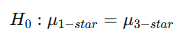

Alternative Hypothesis (H₁):

There is a significant difference in average review length between 1-star and 3-star reviews.

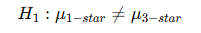

#### 2. Perform an appropriate statistical test.

In [212]:
# ==========================================
# Hypothesis 3: 1-Star vs 3-Star Review Length
# ==========================================


one_star = merged_df[merged_df['rating'] == 1]['review_length'].dropna()
three_star = merged_df[merged_df['rating'] == 3]['review_length'].dropna()

t_stat, p_value = ttest_ind(one_star, three_star, equal_var=False)

print("1-Star Mean Length:", round(one_star.mean(),2))
print("3-Star Mean Length:", round(three_star.mean(),2))
print("T-statistic:", round(t_stat,3))
print("P-value:", p_value)

1-Star Mean Length: 255.98
3-Star Mean Length: 314.83
T-statistic: -4.976
P-value: 6.957226074890723e-07


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test (Welch’s)

##### Why did you choose the specific statistical test?

Comparing mean review length of two independent groups.

Review length is numeric.

Groups are distinct rating categories.

Since p-value < 0.05,
We reject the Null Hypothesis (H₀).

There is a statistically significant difference in review length.

However:

3-star reviews are actually longer than 1-star reviews.

The negative t-statistic confirms the direction.

This contradicts the initial assumption from visual inspection.

## ***6. Feature Engineering & Data Pre-processing***

In [213]:
restaurant_df = merged_df.groupby("restaurant").agg({
    "rating": "mean",
    "review_length": "mean",
    "review": "count",
    "cost": "first",
    "cuisines": "first",
    "collections": "first"
}).reset_index()

restaurant_df.rename(columns={
    "rating": "avg_rating",
    "review_length": "avg_review_length",
    "review": "review_count"
}, inplace=True)

In [214]:
restaurant_df.head()

,restaurant,avg_rating,avg_review_length,review_count,cost,cuisines,collections
0,10 Downing Street,3.80,375.86,100,1900.0,"North Indian,Chinese,Continental",Trending This Week
1,13 Dhaba,3.48,215.28,100,450.0,North Indian,Veggie Friendly
2,"3B's - Buddies, Bar & Barbecue",4.76,194.53,100,1100.0,"North Indian,Mediterranean,European","Barbecue & Grill, Live Sports Screenings"
3,AB's - Absolute Barbecues,4.88,206.80,100,1500.0,"European,Mediterranean,North Indian","Barbecue & Grill, Great Buffets, Corporate Fav..."
4,Absolute Sizzlers,3.62,245.99,100,750.0,"Continental,American,Chinese",Great Buffets


### 1. Handling Missing Values

In [215]:
# Handling Missing Values & Missing Value Imputation
# Check total missing values column-wise
restaurant_df.isnull().sum()

,0
restaurant,0
avg_rating,0
avg_review_length,0
review_count,0
cost,1
cuisines,1
collections,1


In [216]:
# Drop rows with any missing values
restaurant_df = restaurant_df.dropna()

# Verify shape after dropping
restaurant_df.shape

(99, 7)

#### What all missing value imputation techniques have you used and why did you use those techniques?

**Missing Values Identified:**

In the restaurant_df dataset, the following columns had missing values:

  *  cost → 1 missing value

  *  cuisines → 1 missing value

  *  collections → 1 missing value

All other columns had 0 missing values.

**Technique Used: Row Deletion (Drop Missing Values)**

We used:

`restaurant_df = restaurant_df.dropna()`

**Why This Technique Was Used**

*  Very Small Proportion of Missing Data

*  Only 1 row out of 100 restaurants (1% of data).

*  Dropping 1% does not impact overall distribution or clustering outcome.

*  Clustering Models Cannot Handle Missing Values

*  K-Means and StandardScaler do not support NaN values.

*  Imputation would be mandatory if we did not drop.

*  Avoid Artificial Bias in Clustering

*  Imputing cost using mean/median could distort price-based segmentation.

*  Imputing cuisines or collections could create incorrect categorical signals.

Since clustering depends heavily on these features, inaccurate imputation could lead to misleading clusters.

*  Cleaner ML Pipeline

*  Dropping ensures data integrity.

*  Maintains genuine restaurant characteristics.

*  Prevents introduction of synthetic patterns.

### 2. Handling Outliers

In [217]:
# Handling Outliers & Outlier treatments

# Selecting numeric columns
numeric_cols = ["avg_rating", "avg_review_length", "review_count", "cost"]

# IQR Outlier Detection
for col in numeric_cols:
    Q1 = restaurant_df[col].quantile(0.25)
    Q3 = restaurant_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = restaurant_df[(restaurant_df[col] < lower_bound) |
                             (restaurant_df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {outliers.shape[0]}")


Column: avg_rating
Lower Bound: 2.3287500000000003
Upper Bound: 4.75875
Number of Outliers: 3

Column: avg_review_length
Lower Bound: -65.22249999999994
Upper Bound: 614.7974999999999
Number of Outliers: 0

Column: review_count
Lower Bound: 100.0
Upper Bound: 100.0
Number of Outliers: 9

Column: cost
Lower Bound: -550.0
Upper Bound: 2250.0
Number of Outliers: 2


##### What all outlier treatment techniques have you used and why did you use those techniques?

**Outlier Detection Technique Used:**

We used the Interquartile Range (IQR) Method to detect outliers in numeric features (avg_rating, avg_review_length, review_count, cost).

IQR Method:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

This method is robust and works well for skewed data.

**Outlier Treatment Applied:**

No outliers were removed or capped.

**Why No Removal Was Done:**

*  The detected outliers in avg_rating and cost represent genuine premium or high-performing restaurants, not data errors.

*  Clustering is meant to identify such natural business segments.

*  Removing them would distort the real restaurant distribution.

*  No impossible or invalid values were found.

*  The dataset size is small (100 restaurants), so removing rows could affect segmentation quality.

### 3. Categorical Encoding

In [218]:
# Encode your categorical columns

# Extract primary cuisine (first cuisine listed)
restaurant_df["primary_cuisine"] = restaurant_df["cuisines"].str.split(",").str[0]

# Check unique primary cuisines
restaurant_df["primary_cuisine"].nunique()

31

In [219]:
# Remove leading/trailing spaces
restaurant_df["primary_cuisine"] = restaurant_df["primary_cuisine"].str.strip()

# Recalculate top 8 cuisines
top_cuisines = restaurant_df["primary_cuisine"].value_counts().nlargest(8).index

# Replace rare cuisines with 'Other'
restaurant_df["primary_cuisine"] = restaurant_df["primary_cuisine"].apply(
    lambda x: x if x in top_cuisines else "Other"
)

# Check new unique count
restaurant_df["primary_cuisine"].nunique()

9

In [220]:
# Apply One-Hot Encoding
restaurant_df = pd.get_dummies(
    restaurant_df,
    columns=["primary_cuisine"],
    drop_first=True
)

# Check shape after encoding
restaurant_df.shape

(99, 15)

#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical Variables:

`cuisines`

`collections`

---

**Primary Cuisine Extraction**

The cuisines column originally contained multiple cuisines separated by commas.
To reduce dimensionality and avoid creating too many sparse dummy variables, we extracted only the first (primary) cuisine.

Why?

*  Multi-label encoding would create 30+ sparse features.

*  The primary cuisine represents the dominant restaurant identity.

*  Helps maintain cluster stability.

Since there were 31 unique cuisines and only 99 restaurants, we grouped less frequent cuisines into an "Other" category (kept top 8 most frequent cuisines).

---

**Rare Category Grouping**

Why?

*  Reduces dimensionality.

*  Avoids sparse matrix issues.

*  Prevents overfitting in clustering.

*  Improves interpretability.

---

**One-Hot Encoding (OHE)**

We applied One-Hot Encoding to the primary_cuisine column using drop_first=True.

Why?

*  Clustering algorithms require numerical input.

*  OHE does not assume any ordinal relationship between categories.

*  Preserves category independence.

*  drop_first=True reduces redundancy and keeps the feature space compact.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [221]:
# Expand Contraction

!pip install contractions

In [222]:
import contractions

# Create a new column to preserve original text
merged_df["review_expanded"] = merged_df["review"].apply(
    lambda x: contractions.fix(x) if isinstance(x, str) else x
)

# Check output
merged_df[["review", "review_expanded"]].head()

,review,review_expanded
0,"The ambience was good, food was quite good . h...","The ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...,Ambience is too good for a pleasant evening. S...
2,A must try.. great food great ambience. Thnx f...,A must try.. great food great ambience. Thnx f...
3,Soumen das and Arun was a great guy. Only beca...,Soumen das and Arun was a great guy. Only beca...
4,Food is good.we ordered Kodi drumsticks and ba...,Food is good.we ordered Kodi drumsticks and ba...


#### 2. Lower Casing

In [223]:
# Convert expanded text to lowercase
merged_df["review_lower"] = merged_df["review_expanded"].str.lower()

# Check output
merged_df[["review_expanded", "review_lower"]].head()

,review_expanded,review_lower
0,"The ambience was good, food was quite good . h...","the ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...,ambience is too good for a pleasant evening. s...
2,A must try.. great food great ambience. Thnx f...,a must try.. great food great ambience. thnx f...
3,Soumen das and Arun was a great guy. Only beca...,soumen das and arun was a great guy. only beca...
4,Food is good.we ordered Kodi drumsticks and ba...,food is good.we ordered kodi drumsticks and ba...


#### 3. Removing Punctuations

In [224]:
# Remove Punctuations
import re

# Remove punctuation
merged_df["review_no_punct"] = merged_df["review_lower"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x) if isinstance(x, str) else x
)

# Check output
merged_df[["review_lower", "review_no_punct"]].head()

,review_lower,review_no_punct
0,"the ambience was good, food was quite good . h...",the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening. s...,ambience is too good for a pleasant evening se...
2,a must try.. great food great ambience. thnx f...,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy. only beca...,soumen das and arun was a great guy only becau...
4,food is good.we ordered kodi drumsticks and ba...,food is goodwe ordered kodi drumsticks and bas...


#### 4. Removing URLs & Removing words and digits contain digits.

In [225]:
# Remove URLs
merged_df["review_no_url"] = merged_df["review_no_punct"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x) if isinstance(x, str) else x
)

# Remove words containing digits
merged_df["review_no_digits"] = merged_df["review_no_url"].apply(
    lambda x: re.sub(r"\w*\d\w*", "", x) if isinstance(x, str) else x
)

# Check output
merged_df[["review_no_punct", "review_no_digits"]].head()

,review_no_punct,review_no_digits
0,the ambience was good food was quite good had...,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...,food is goodwe ordered kodi drumsticks and bas...


#### 5. Removing Stopwords & Removing White spaces

In [226]:
# Remove Stopwords

from nltk.corpus import stopwords

# Download stopwords if not already
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Remove stopwords
merged_df["review_no_stopwords"] = merged_df["review_no_digits"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
    if isinstance(x, str) else x
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [227]:
# Remove extra spaces
merged_df["review_clean"] = merged_df["review_no_stopwords"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip() if isinstance(x, str) else x
)

# Check output
merged_df[["review_no_digits", "review_clean"]].head()

,review_no_digits,review_clean
0,the ambience was good food was quite good had...,ambience good food quite good saturday lunch c...
1,ambience is too good for a pleasant evening se...,ambience good pleasant evening service prompt ...
2,a must try great food great ambience thnx for ...,must try great food great ambience thnx servic...
3,soumen das and arun was a great guy only becau...,soumen das arun great guy behavior sincerety g...
4,food is goodwe ordered kodi drumsticks and bas...,food goodwe ordered kodi drumsticks basket mut...


#### 6. Rephrase Text

In [228]:
# Dictionary for common informal words
slang_dict = {
    "thnx": "thanks",
    "gud": "good",
    "gr8": "great",
    "nyc": "nice",
    "bt": "but",
    "bcz": "because"
}

def normalize_slang(text):
    words = text.split()
    normalized_words = [slang_dict[word] if word in slang_dict else word for word in words]
    return " ".join(normalized_words)

merged_df["review_rephrased"] = merged_df["review_clean"].apply(
    lambda x: normalize_slang(x) if isinstance(x, str) else x
)

# Check output
merged_df[["review_clean", "review_rephrased"]].head()

,review_clean,review_rephrased
0,ambience good food quite good saturday lunch c...,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...,must try great food great ambience thanks serv...
3,soumen das arun great guy behavior sincerety g...,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...,food goodwe ordered kodi drumsticks basket mut...


#### 7. Tokenization

In [229]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [230]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer (run once)
nltk.download('punkt')

# Apply tokenization
merged_df["review_tokens"] = merged_df["review_rephrased"].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else x
)

# Check output
merged_df[["review_rephrased", "review_tokens"]].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,review_rephrased,review_tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thanks serv...,"[must, try, great, food, great, ambience, than..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


#### 8. Text Normalization

In [231]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

from nltk.stem import WordNetLemmatizer
import nltk

# Download wordnet if not already
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Apply lemmatization to tokens
merged_df["review_lemma"] = merged_df["review_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
    if isinstance(tokens, list) else tokens
)

# Check output
merged_df[["review_tokens", "review_lemma"]].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review_tokens,review_lemma
0,"[ambience, good, food, quite, good, saturday, ...","[ambience, good, food, quite, good, saturday, ..."
1,"[ambience, good, pleasant, evening, service, p...","[ambience, good, pleasant, evening, service, p..."
2,"[must, try, great, food, great, ambience, than...","[must, try, great, food, great, ambience, than..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[soumen, da, arun, great, guy, behavior, since..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[food, goodwe, ordered, kodi, drumstick, baske..."


##### Which text normalization technique have you used and why?

Technique Used: Lemmatization

We applied Lemmatization using NLTK’s WordNetLemmatizer to normalize words to their base (dictionary) form.It preserves semantic meaning while reducing redundancy in textual data, making the dataset cleaner and more suitable for further NLP analysis.

#### 9. Part of speech tagging

In [232]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [233]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [234]:
from nltk import pos_tag

merged_df["pos_tags"] = merged_df["review_tokens"].apply(
    lambda tokens: pos_tag(tokens) if isinstance(tokens, list) else tokens
)

merged_df[["review_tokens", "pos_tags"]].head()

,review_tokens,pos_tags
0,"[ambience, good, food, quite, good, saturday, ...","[(ambience, RB), (good, JJ), (food, NN), (quit..."
1,"[ambience, good, pleasant, evening, service, p...","[(ambience, RB), (good, JJ), (pleasant, NN), (..."
2,"[must, try, great, food, great, ambience, than...","[(must, MD), (try, VB), (great, JJ), (food, NN..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[(soumen, NNS), (das, VBP), (arun, RB), (great..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[(food, NN), (goodwe, NN), (ordered, VBD), (ko..."


#### 10. Text Vectorization

In [235]:
# Vectorizing Text

# Join lemmatized tokens into clean string
merged_df["final_text"] = merged_df["review_lemma"].apply(
    lambda tokens: " ".join(tokens) if isinstance(tokens, list) else ""
)

merged_df[["review_lemma", "final_text"]].head()

,review_lemma,final_text
0,"[ambience, good, food, quite, good, saturday, ...",ambience good food quite good saturday lunch c...
1,"[ambience, good, pleasant, evening, service, p...",ambience good pleasant evening service prompt ...
2,"[must, try, great, food, great, ambience, than...",must try great food great ambience thanks serv...
3,"[soumen, da, arun, great, guy, behavior, since...",soumen da arun great guy behavior sincerety go...
4,"[food, goodwe, ordered, kodi, drumstick, baske...",food goodwe ordered kodi drumstick basket mutt...


In [236]:

# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,      # limit features for stability
    ngram_range=(1,1),      # unigrams
    min_df=5                # ignore very rare words
)

# Fit and transform
tfidf_matrix = tfidf.fit_transform(merged_df["final_text"])

# Check shape
tfidf_matrix.shape

(9954, 1000)

In [237]:
# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Add restaurant column to map reviews
tfidf_df["restaurant"] = merged_df["restaurant"].values

tfidf_df.head()

,able,absolute,absolutely,ac,across,actually,add,added,affordable,afternoon,...,wow,wrap,wrong,year,yes,yesterday,yet,yum,yummy,zomato
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [238]:
# Add restaurant column to TF-IDF dataframe
tfidf_df["restaurant"] = merged_df["restaurant"].values

# Aggregate by restaurant (mean of TF-IDF vectors)
restaurant_tfidf = tfidf_df.groupby("restaurant").mean().reset_index()

# Check shape
restaurant_tfidf.shape

(100, 1000)

In [239]:
restaurant_tfidf.head()

,restaurant,able,absolute,absolutely,ac,across,actually,add,added,affordable,...,wow,wrap,wrong,year,yes,yesterday,yet,yum,yummy,zomato
0,10 Downing Street,0.000000,0.000000,0.003683,0.000000,0.004149,0.002090,0.001517,0.002539,0.000000,...,0.000000,0.0,0.003820,0.005323,0.003447,0.002686,0.001026,0.000000,0.001907,0.000905
1,13 Dhaba,0.000000,0.000000,0.001641,0.002844,0.000000,0.001376,0.000000,0.001611,0.006865,...,0.003048,0.0,0.000000,0.002655,0.000000,0.006142,0.007444,0.000000,0.006593,0.012533
2,"3B's - Buddies, Bar & Barbecue",0.000000,0.000000,0.003434,0.000000,0.000000,0.000000,0.004769,0.000000,0.008148,...,0.003766,0.0,0.000000,0.000000,0.003771,0.000000,0.000000,0.005009,0.000000,0.000000
3,AB's - Absolute Barbecues,0.000000,0.005061,0.010192,0.000000,0.002702,0.000000,0.000000,0.000000,0.000000,...,0.001935,0.0,0.000000,0.000000,0.003709,0.006122,0.000000,0.000000,0.001839,0.000000
4,Absolute Sizzlers,0.004181,0.088466,0.022584,0.000000,0.002097,0.000000,0.006325,0.005170,0.000000,...,0.006134,0.0,0.003628,0.000000,0.000000,0.000000,0.000000,0.000000,0.001941,0.013725


##### Which text vectorization technique have you used and why?

**Technique Used: TF-IDF (Term Frequency – Inverse Document Frequency)**

We used TF-IDF to convert cleaned textual reviews into numerical feature vectors.

**Why TF-IDF Was Used:**

*  It assigns higher weight to words that are important within a review but not too common across all reviews.

*  It reduces the influence of very frequent words that do not add meaningful information.

*  It provides a normalized numerical representation suitable for distance-based algorithms like K-Means.

*  Dimensionality was controlled using max_features=1000 to avoid high sparsity and instability.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [240]:
# Save restaurant names
restaurant_names = restaurant_tfidf['restaurant']

# Remove restaurant column from TFIDF matrix
tfidf_features = restaurant_tfidf.drop(columns=['restaurant'])

# Check shape
tfidf_features.shape

(100, 999)

In [241]:
# Apply PCA to reduce TF-IDF dimensions
pca = PCA(n_components=20, random_state=42)

tfidf_pca = pca.fit_transform(tfidf_features)

# Convert to dataframe
tfidf_pca_df = pd.DataFrame(
    tfidf_pca,
    columns=[f'PCA_{i+1}' for i in range(20)]
)

# Add restaurant names back
tfidf_pca_df.insert(0, 'restaurant', restaurant_names.values)

tfidf_pca_df.head()

,restaurant,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20
0,10 Downing Street,-0.107377,0.010211,-0.028864,0.085371,-0.015883,0.002963,0.003867,0.008131,0.001152,...,-0.005524,0.005109,-0.003498,0.008666,0.006561,-0.006953,0.007692,-0.001853,0.023099,0.010484
1,13 Dhaba,0.041695,-0.041874,0.035929,0.010466,-0.071800,-0.042812,0.028738,-0.098182,-0.022399,...,0.043876,-0.007420,0.016737,0.017377,0.004732,-0.001214,0.004921,-0.011049,0.013431,-0.012036
2,"3B's - Buddies, Bar & Barbecue",-0.065011,0.121654,-0.036583,-0.120097,0.029150,-0.045152,-0.058669,-0.024879,-0.034989,...,-0.000299,-0.023404,0.084753,0.017651,-0.057055,0.040429,-0.050042,0.060808,-0.072897,0.014733
3,AB's - Absolute Barbecues,-0.055151,0.114189,-0.037032,-0.133070,0.017986,-0.033373,-0.052541,-0.030780,-0.033045,...,-0.002788,-0.000830,0.074839,0.035983,-0.042617,0.006965,-0.011546,-0.024336,-0.003786,-0.009185
4,Absolute Sizzlers,-0.058704,0.002231,0.034949,-0.024588,0.003754,-0.019575,-0.010505,0.009038,-0.018649,...,-0.009711,-0.022402,0.020512,-0.085978,0.027641,0.149731,0.198125,-0.011720,-0.007667,-0.009523


In [242]:
pca.explained_variance_ratio_.sum()

np.float64(0.6791035977093723)

In [243]:
# Clean restaurant names before merging

restaurant_df['restaurant'] = restaurant_df['restaurant'].str.strip().str.lower()
tfidf_pca_df['restaurant'] = tfidf_pca_df['restaurant'].str.strip().str.lower()

In [244]:
final_df = restaurant_df.merge(
    tfidf_pca_df,
    on="restaurant",
    how="inner"
)

final_df.shape

(99, 35)

#### 2. Feature Selection

In [245]:
clustering_df = final_df[
    ['avg_rating','avg_review_length','review_count','cost'] +
    [f'PCA_{i}' for i in range(1,11)]
]

clustering_df.shape

(99, 14)

##### What all feature selection methods have you used  and why?

**Feature Selection Methods Used**

**1. Domain Knowledge Based Selection**

Restaurant performance is influenced by variables such as:

*  avg_rating

*  review_count

*  avg_review_length

*  cost

These features directly reflect customer satisfaction, engagement, and pricing strategy, which are important for restaurant segmentation.

**2. Text Feature Extraction using TF-IDF**

Customer reviews contain valuable information about food quality, service, ambience, and experience.

TF-IDF was used to convert textual review data into numerical features, allowing the clustering algorithm to capture patterns in customer feedback.

**3. Dimensionality Reduction using PCA**

TF-IDF generated 999 text features, which is too high for clustering.

To reduce noise and computational complexity, Principal Component Analysis (PCA) was applied to reduce these features to 20 principal components while retaining ~67.9% variance.

This helped improve cluster stability and avoid the curse of dimensionality.

**4. Removal of Non-Numerical / Irrelevant Features**

Features such as:

*  restaurant name
*  cuisines
*  collections

were removed because they are categorical text variables and would not directly contribute to numerical clustering without complex encoding.

---

**Why these methods were used**

The feature selection process ensured that:

*  Only meaningful behavioral and textual features were used

*  High-dimensional text data was compressed without losing important information

*  Noise and irrelevant features were removed to improve clustering performance



##### Which all features you found important and why?

**Important Features Identified**

The following features were most useful in differentiating restaurant segments:

**1️⃣ Average Rating (avg_rating)**

Represents customer satisfaction and quality perception.

Restaurants with higher ratings tend to belong to premium or highly preferred segments, making this a strong clustering feature.

**2️⃣ Cost (cost)**

Cost is one of the most important differentiators in restaurant segmentation.

It helps distinguish between:

*  premium restaurants
*  mid-range restaurants
*  budget restaurants

**3️⃣ Review Count (review_count)**

Indicates restaurant popularity and customer engagement.

Restaurants with higher review counts generally have higher visibility and customer traffic.

**4️⃣ Average Review Length (avg_review_length)**

This represents depth of customer feedback.

Longer reviews often indicate higher engagement or stronger experiences, helping differentiate restaurant types.


**5️⃣ PCA Text Features (PCA_1 – PCA_10)**

These features summarize patterns in customer reviews, capturing information about:

*  food quality

*  service

*  ambience

*  customer experience

They help group restaurants with similar customer feedback patterns.


### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data required transformation before applying clustering algorithms.

**Transformation Used**

    *  Feature Scaling using StandardScaler

Clustering algorithms such as KMeans, Hierarchical Clustering, and Gaussian Mixture Models rely on distance-based calculations to group similar data points. Since the dataset contained features with different scales, feature scaling was necessary.

**For example:**

**Feature	Typical Range**

    *  avg_rating	1 – 5

    *  review_count	up to ~100

    *  cost	up to ~2000

    *  PCA components	small decimal values

If the data were not scaled, features with larger magnitudes (such as cost) would dominate the distance calculations, causing the clustering algorithm to give them disproportionately higher importance.

To avoid this issue, StandardScaler was applied, which standardizes the data by transforming each feature to have a mean of 0 and a standard deviation of 1.

**Why this transformation was necessary**

*  Ensures all features contribute equally to clustering

*  Prevents large-scale variables from dominating distance calculations

*  Improves cluster separation and model performance

*  Helps algorithms like KMeans and Hierarchical Clustering perform more effectively

Thus, feature scaling was an essential transformation step to ensure reliable and meaningful clustering results.

### 7. Data Scaling

**Applying Standard Scaler**

In [246]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(clustering_df)

# Convert back to dataframe for readability
X_scaled = pd.DataFrame(X_scaled, columns=clustering_df.columns)

X_scaled.head()

,avg_rating,avg_review_length,review_count,cost,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10
0,0.384903,0.756293,0.16965,2.032450,-1.242168,0.174091,-0.539020,1.856660,-0.373595,0.074587,0.107941,0.225447,0.037462,-0.589025
1,-0.245885,-0.511556,0.16965,-0.833544,0.476860,-0.686929,0.690459,0.225218,-1.678602,-1.046858,0.755685,-2.709465,-0.631142,-1.391381
2,2.277267,-0.675386,0.16965,0.451212,-0.753620,2.016361,-0.685497,-2.618464,0.677411,-1.104191,-1.520722,-0.685834,-0.988543,0.426942
3,2.513812,-0.578509,0.16965,1.241831,-0.639922,1.892960,-0.694015,-2.901010,0.416863,-0.815596,-1.361138,-0.848754,-0.933370,0.548423
4,0.030085,-0.269087,0.16965,-0.240580,-0.680892,0.042184,0.671873,-0.538265,0.084690,-0.477568,-0.266364,0.250481,-0.524674,0.878610


##### Which method have you used to scale you data and why?

The data was scaled using **StandardScaler.**

**Why StandardScaler was used**

StandardScaler standardizes the features by transforming them so that they have a mean of 0 and a standard deviation of 1. This ensures that all variables are placed on a common scale.

In the dataset, different features had very different ranges.

**For example:**

*  cost had values in the hundreds or thousands

*  avg_rating ranged between about 1 to 5

*  review_count had values around tens or hundreds

*  PCA features had small decimal values

If the data were not scaled, features with larger values (such as cost) would dominate the distance calculations used by clustering algorithms.

Since clustering algorithms like KMeans, Hierarchical Clustering, and Gaussian Mixture Models rely on distance-based calculations, StandardScaler helps ensure that:

*  All features contribute equally to the clustering process

*  No single feature dominates the clustering due to its scale

*  The clustering results become more balanced and meaningful

Therefore, StandardScaler was used to standardize the dataset before applying clustering models.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

**Yes, dimensionality reduction was necessary in this project.**

The dataset included text-based review features that were converted into numerical form using TF-IDF, which produced a very large number of features (around 999). High-dimensional data can introduce several issues such as increased computational complexity, redundancy, and noise.

When a dataset contains too many features, clustering algorithms may struggle to identify meaningful patterns due to the curse of dimensionality, where distances between data points become less informative. This can negatively affect the quality of clusters.

Therefore, dimensionality reduction was required to simplify the feature space while preserving the most important information, making the clustering process more efficient and reliable.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**The dimensionality reduction technique used in this project was Principal Component Analysis (PCA).**

PCA transforms the original high-dimensional features into a smaller set of principal components that capture most of the variance present in the data. In this project, PCA was applied to the TF-IDF features, reducing them from approximately 999 features to 20 principal components, while retaining about 67.9% of the total variance.

**PCA was chosen because:**

*  It effectively reduces dimensionality while preserving important information in the data.

*  It helps remove noise and redundant features present in high-dimensional text data.

*  It improves the efficiency and stability of clustering algorithms.

*  It helps avoid the curse of dimensionality, allowing clustering models to detect clearer patterns.

By reducing the number of features while retaining most of the meaningful variance, PCA made the dataset more suitable for clustering analysis.

### 9. Data Splitting

##### What data splitting ratio have you used and why?

**No data splitting (such as train-test split) was used in this project.**

*This is because the project uses unsupervised learning techniques, specifically clustering algorithms such as KMeans, Agglomerative Hierarchical Clustering, and Gaussian Mixture Model.* Unlike supervised learning, clustering does not rely on a target variable or labeled data.

Since the objective of clustering is to identify natural patterns or groupings within the dataset, the entire dataset is used to allow the algorithm to learn the complete structure of the data.

Therefore, instead of splitting the dataset into training and testing sets, the full dataset was used for clustering, and the model performance was evaluated using the Silhouette Score, which measures how well the data points fit within their assigned clusters compared to other clusters.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**No, the concept of dataset imbalance is not applicable in this project.**

Dataset imbalance typically refers to situations in supervised learning, where the target variable has unequal class distributions (for example, significantly more instances of one class compared to another). This can affect the model’s ability to correctly learn patterns for minority classes.

However, this project uses unsupervised learning techniques (clustering) such as KMeans, Agglomerative Hierarchical Clustering, and Gaussian Mixture Model. In clustering, there is no predefined target variable or class labels in the dataset.

Since the objective is to discover natural groupings within the data rather than predict predefined classes, the concept of class imbalance does not apply. The clustering algorithms automatically determine cluster structures based on similarities among the features in the dataset.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

## ***7. ML Model Implementation***

### **MODEL -1 KMeans**

#### **Baseline Kmeans**

**Fit Model**

In [247]:
# Baseline KMeans model
kmeans_baseline = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit model
kmeans_baseline.fit(X_scaled)

# Get cluster labels
baseline_labels = kmeans_baseline.labels_

In [248]:
baseline_labels[:10]

array([2, 1, 2, 2, 1, 1, 0, 1, 2, 1], dtype=int32)

**Silhouette Score**

In [249]:
# Calculate silhouette score
kmeans_baseline_sil = silhouette_score(X_scaled, baseline_labels)

kmeans_baseline_sil

np.float64(0.1628020541989798)

**Elbow Method**

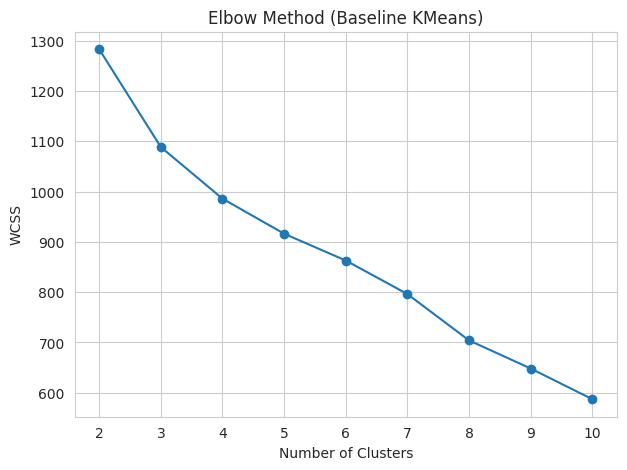

In [250]:
wcss = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method (Baseline KMeans)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**Silhouette Score Visualization (Baseline)**

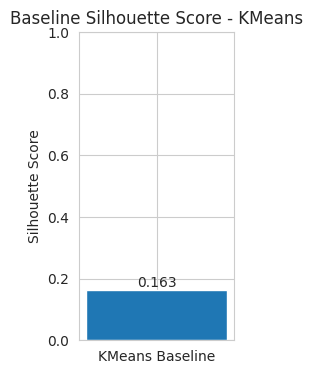

In [251]:
plt.figure(figsize=(2,4))

plt.bar(
    ["KMeans Baseline"],
    [kmeans_baseline_sil]
)

# Set Y-axis range
plt.ylim(0,1)

# Show value on top of bar
plt.text(
    0,
    kmeans_baseline_sil + 0.01,
    round(kmeans_baseline_sil,3),
    ha='center'
)

plt.ylabel("Silhouette Score")
plt.title("Baseline Silhouette Score - KMeans")

plt.show()

#### **Tuned Kmeans**

**Fit Model**

In [252]:
best_k = None
best_score = -1
best_model = None

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        algorithm="lloyd",
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k={k}  silhouette={score}")

    if score > best_score:
        best_score = score
        best_k = k
        best_model = kmeans

k=2  silhouette=0.1638867799965216
k=3  silhouette=0.17011963497007918
k=4  silhouette=0.15591657585700183
k=5  silhouette=0.1521263047802076
k=6  silhouette=0.15420772919067255
k=7  silhouette=0.17344643783462546
k=8  silhouette=0.19356892978396015
k=9  silhouette=0.1965304037385119
k=10  silhouette=0.21680210051120782


**Silhouette Score**

In [253]:
best_k, best_score

(10, np.float64(0.21680210051120782))

**Elbow Method**

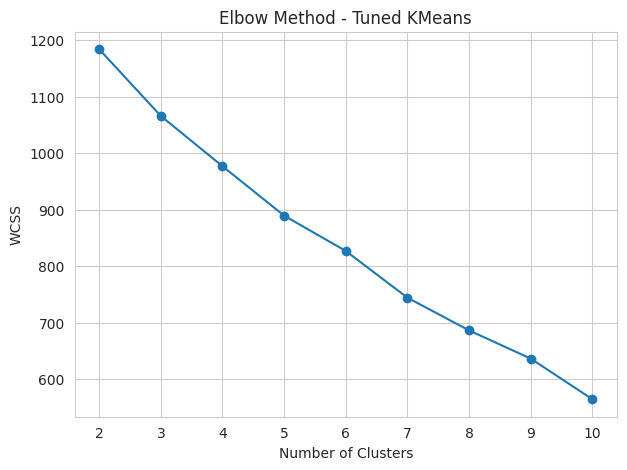

In [258]:
wcss = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Method - Tuned KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

**Silhouette Score Visualization (Baseline vs Tuned)**

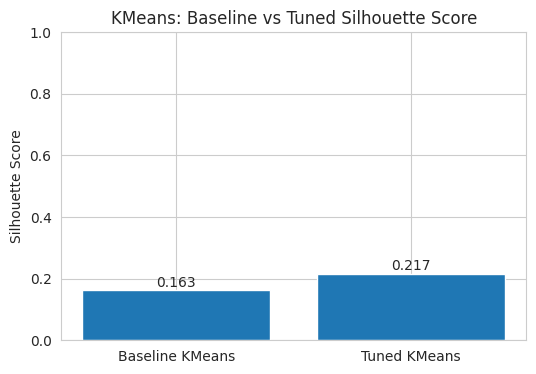

In [259]:
scores = [kmeans_baseline_sil, best_score]

labels = ["Baseline KMeans", "Tuned KMeans"]

plt.figure(figsize=(6,4))

plt.bar(labels, scores)

# Y-axis range
plt.ylim(0,1)

# Show values on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, round(v,3), ha='center')

plt.ylabel("Silhouette Score")
plt.title("KMeans: Baseline vs Tuned Silhouette Score")

plt.show()

### **MODEL -2 Agglomerative Hierarchical Clustering**

#### **Baseline Agglomerative Hierarchical Clustering**

**Fit Model**

In [261]:
# Baseline Hierarchical Model
hier_baseline = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

# Fit model
hier_labels = hier_baseline.fit_predict(X_scaled)

In [262]:
hier_labels[:10]

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

**Silhouette Score**

In [263]:
# Baseline silhouette score
hier_baseline_sil = silhouette_score(X_scaled, hier_labels)

hier_baseline_sil

np.float64(0.15900511789987493)

**Dendrogram Visualization**

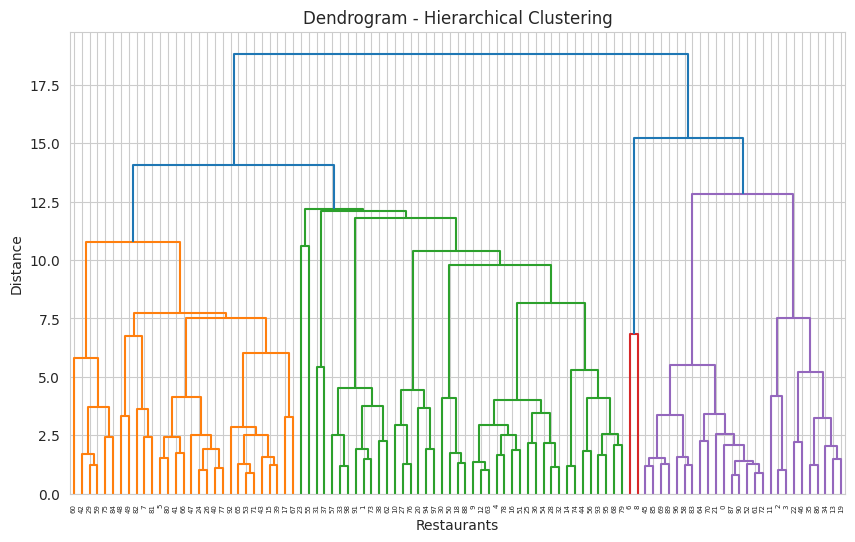

In [264]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Restaurants")
plt.ylabel("Distance")

plt.show()

**Silhouette Score Visualization (Baseline)**

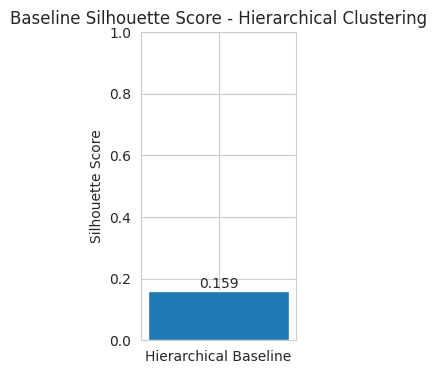

In [265]:
plt.figure(figsize=(2,4))

plt.bar(
    ["Hierarchical Baseline"],
    [hier_baseline_sil]
)

# Y-axis range
plt.ylim(0,1)

# Show value on bar
plt.text(
    0,
    hier_baseline_sil + 0.01,
    round(hier_baseline_sil,3),
    ha='center'
)

plt.ylabel("Silhouette Score")
plt.title("Baseline Silhouette Score - Hierarchical Clustering")

plt.show()

#### **Tuned Agglomerative Hierarchical Clustering**

**Fit Model**

In [260]:
best_score_hier = -1
best_params_hier = None
best_labels_hier = None

for linkage in ['ward','complete','average','single']:

    for k in range(2,11):

        if linkage == "ward":
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage,
                metric='euclidean'
            )

        labels = model.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        print(f"linkage={linkage}, k={k}, silhouette={score}")

        if score > best_score_hier:
            best_score_hier = score
            best_params_hier = (linkage, k)
            best_labels_hier = labels

linkage=ward, k=2, silhouette=0.15900511789987493
linkage=ward, k=3, silhouette=0.14209048094939253
linkage=ward, k=4, silhouette=0.1355096538752054
linkage=ward, k=5, silhouette=0.13796425967606313
linkage=ward, k=6, silhouette=0.14508923079483207
linkage=ward, k=7, silhouette=0.15700656810327251
linkage=ward, k=8, silhouette=0.18068540672214828
linkage=ward, k=9, silhouette=0.19909099759542778
linkage=ward, k=10, silhouette=0.2021570103713368
linkage=complete, k=2, silhouette=0.4757687572093894
linkage=complete, k=3, silhouette=0.40451042855082187
linkage=complete, k=4, silhouette=0.3764010615124965
linkage=complete, k=5, silhouette=0.3779028486944443
linkage=complete, k=6, silhouette=0.15009841732037624
linkage=complete, k=7, silhouette=0.14267060226055997
linkage=complete, k=8, silhouette=0.1600338939642747
linkage=complete, k=9, silhouette=0.18046808065739883
linkage=complete, k=10, silhouette=0.1899485322048096
linkage=average, k=2, silhouette=0.4757687572093894
linkage=average, 

**Silhouette Score**

In [266]:
best_params_hier, best_score_hier

(('single', 2), np.float64(0.5565709098173535))

**Dendrogram Visualization (Tuned)**

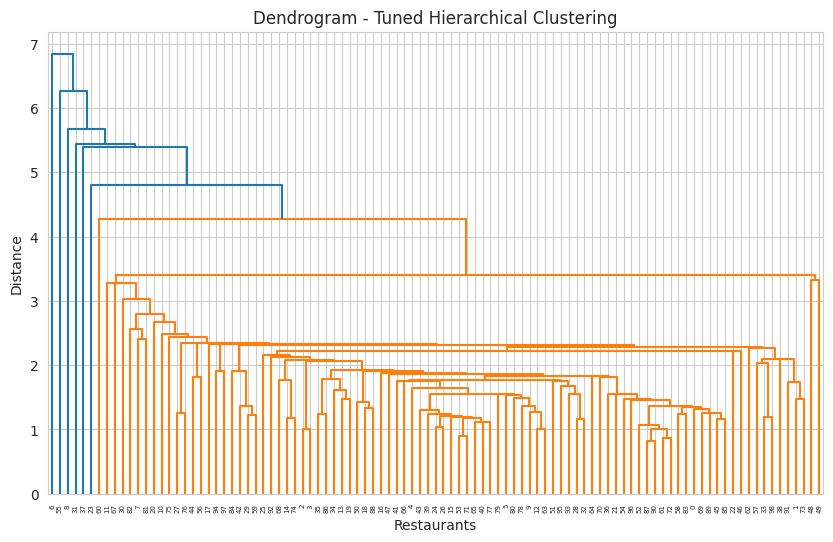

In [268]:
linked = linkage(X_scaled, method='single')

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Dendrogram - Tuned Hierarchical Clustering")
plt.xlabel("Restaurants")
plt.ylabel("Distance")

plt.show()

**Silhouette Score Visualization (Baseline vs Tuned)**

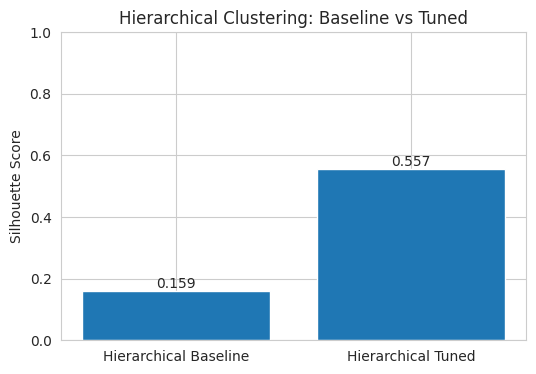

In [269]:
scores = [hier_baseline_sil, best_score_hier]

labels = ["Hierarchical Baseline", "Hierarchical Tuned"]

plt.figure(figsize=(6,4))

plt.bar(labels, scores)

# Y-axis range
plt.ylim(0,1)

# Show values on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, round(v,3), ha='center')

plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering: Baseline vs Tuned")

plt.show()

### **MODEL -3 Gaussian Mixture Model (GMM)**

#### **Baseline Gaussian Mixture Model**

**Fit Model**

In [270]:
# Baseline GMM model
gmm_baseline = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

# Fit model
gmm_baseline.fit(X_scaled)

# Predict cluster labels
gmm_labels = gmm_baseline.predict(X_scaled)

In [271]:
gmm_labels[:10]

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

**Silhouette Score**

In [272]:
# Baseline silhouette score
gmm_baseline_sil = silhouette_score(X_scaled, gmm_labels)

gmm_baseline_sil

np.float64(0.4457325851042244)

**Cluster Visualization**

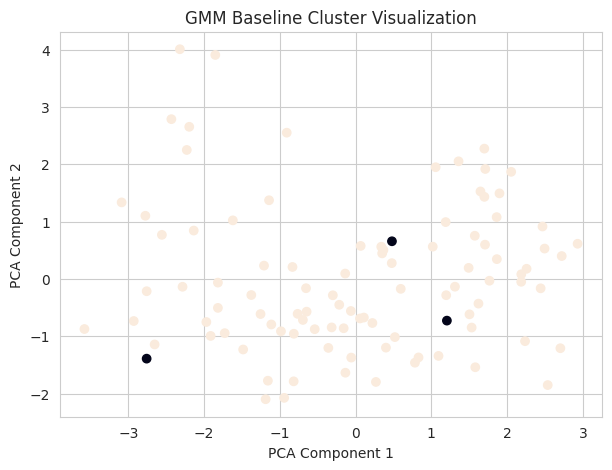

In [273]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels,
)

plt.title("GMM Baseline Cluster Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

**Silhouette Score Visualization (Baseline)**

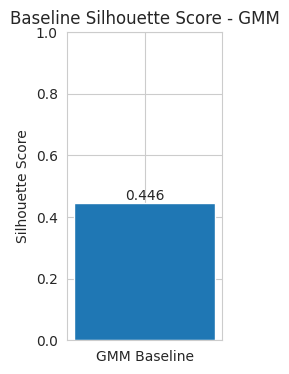

In [274]:
plt.figure(figsize=(2,4))

plt.bar(
    ["GMM Baseline"],
    [gmm_baseline_sil]
)

# Y axis range
plt.ylim(0,1)

# show value on bar
plt.text(
    0,
    gmm_baseline_sil + 0.01,
    round(gmm_baseline_sil,3),
    ha='center'
)

plt.ylabel("Silhouette Score")
plt.title("Baseline Silhouette Score - GMM")

plt.show()

#### **Tuned Gaussian Mixture Model**

**Fit Model**

In [275]:
best_score_gmm = -1
best_params_gmm = None
best_labels_gmm = None

for k in range(2,11):

    for cov in ['full','tied','diag','spherical']:

        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            init_params='kmeans',
            max_iter=500,
            random_state=42
        )

        labels = gmm.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        print(f"components={k}, covariance={cov}, silhouette={score}")

        if score > best_score_gmm:
            best_score_gmm = score
            best_params_gmm = (k, cov)
            best_labels_gmm = labels

components=2, covariance=full, silhouette=0.4457325851042244
components=2, covariance=tied, silhouette=0.4457325851042244
components=2, covariance=diag, silhouette=0.4457325851042244
components=2, covariance=spherical, silhouette=0.24060550354758986
components=3, covariance=full, silhouette=0.15881192094586957
components=3, covariance=tied, silhouette=0.16267866559715116
components=3, covariance=diag, silhouette=0.12374863759759791
components=3, covariance=spherical, silhouette=0.10537341262549266
components=4, covariance=full, silhouette=0.16126097743615628
components=4, covariance=tied, silhouette=0.16182831249257773
components=4, covariance=diag, silhouette=0.13559606412308375
components=4, covariance=spherical, silhouette=0.12552723604963487
components=5, covariance=full, silhouette=0.1550192760085031
components=5, covariance=tied, silhouette=0.1516289913850935
components=5, covariance=diag, silhouette=0.05285299407595778
components=5, covariance=spherical, silhouette=0.09980324465

**Silhouette Score**

In [276]:
best_params_gmm, best_score_gmm

((2, 'full'), np.float64(0.4457325851042244))

**Cluster Visualization (Tuned)**

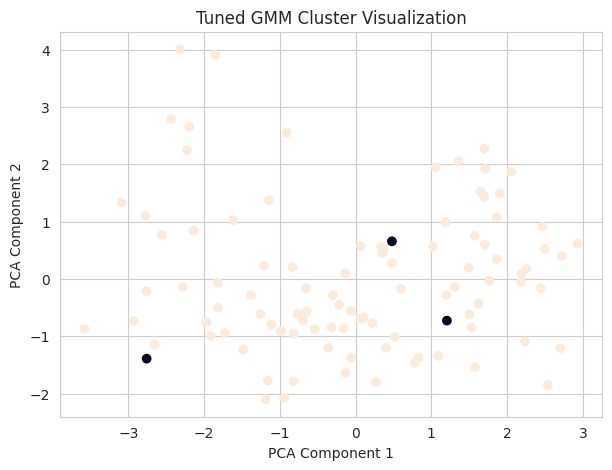

In [277]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_labels_gmm
)

plt.title("Tuned GMM Cluster Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

**Silhouette Score Visualization (Baseline vs Tuned)**

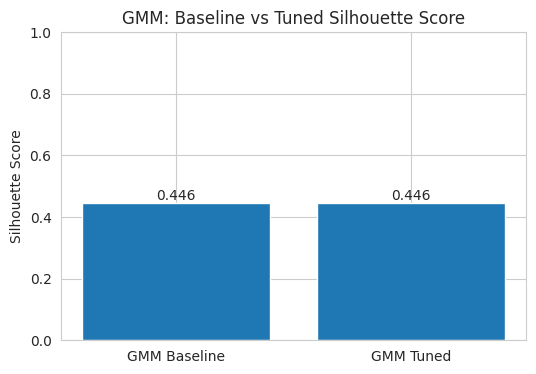

In [278]:
scores = [gmm_baseline_sil, best_score_gmm]

labels = ["GMM Baseline", "GMM Tuned"]

plt.figure(figsize=(6,4))

plt.bar(labels, scores)

# Y-axis range
plt.ylim(0,1)

# show values
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, round(v,3), ha='center')

plt.ylabel("Silhouette Score")
plt.title("GMM: Baseline vs Tuned Silhouette Score")

plt.show()

### **MODEL -4 DBSCAN**

#### **Baseline DBSCAN**

**Cluster Visualization**

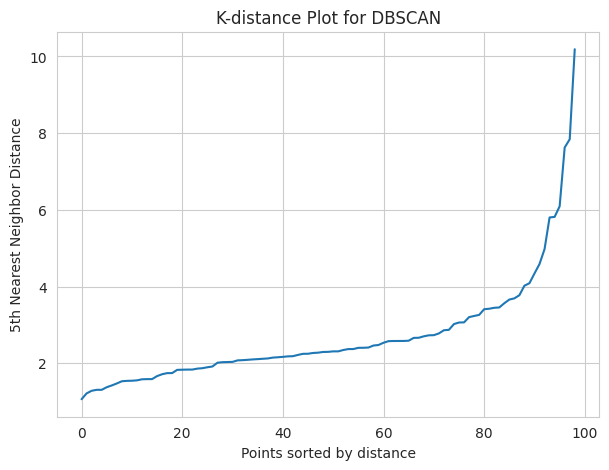

In [279]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(7,5))

plt.plot(distances)

plt.title("K-distance Plot for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")

plt.show()

**Fit Model**

In [280]:
dbscan_baseline = DBSCAN(
    eps=2.5,
    min_samples=4
)

dbscan_labels = dbscan_baseline.fit_predict(X_scaled)

In [281]:
print(dbscan_labels[:10])
print(np.unique(dbscan_labels))

[ 0  0  0  0  0  0 -1 -1 -1  0]
[-1  0]


In [282]:
np.unique(dbscan_labels)

array([-1,  0])

DBSCAN was tested as a density-based clustering approach. However, the algorithm identified only a single dense cluster with several noise points. Since DBSCAN requires multiple dense regions to form clusters, it was not suitable for this dataset. Therefore, silhouette score could not be meaningfully evaluated for DBSCAN.

### **Final Model Comparison Visualization**

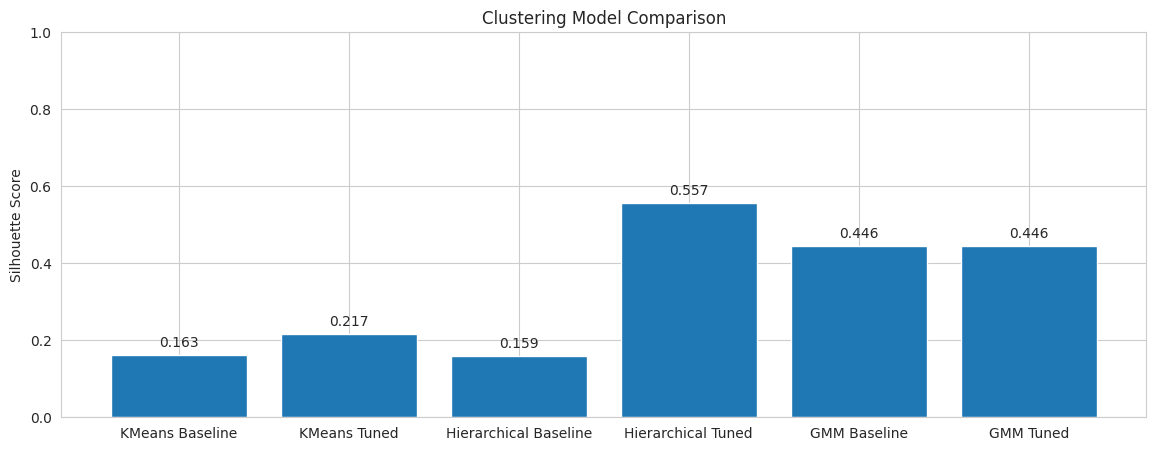

In [283]:
models = [
    "KMeans Baseline",
    "KMeans Tuned",
    "Hierarchical Baseline",
    "Hierarchical Tuned",
    "GMM Baseline",
    "GMM Tuned"
]

scores = [
    kmeans_baseline_sil,
    best_score,              # KMeans tuned
    hier_baseline_sil,
    best_score_hier,
    gmm_baseline_sil,
    best_score_gmm
]

plt.figure(figsize=(14,5))

plt.bar(models, scores)

plt.ylim(0,1)

for i,v in enumerate(scores):
    plt.text(i, v+0.02, round(v,3), ha='center')

plt.xticks(rotation=0)

plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")

plt.show()

### **Cluster Profiling**

**Add cluster labels**

In [284]:
final_df["Cluster"] = best_labels_hier

**Cluster Summary Table**

In [285]:
cluster_profile = final_df.groupby("Cluster").agg({
    "avg_rating":"mean",
    "avg_review_length":"mean",
    "review_count":"mean",
    "cost":"mean"
})

cluster_profile

,avg_rating,avg_review_length,review_count,cost
Cluster,,,,
0,3.600970,277.623214,99.765306,874.489796
1,3.974026,519.987013,77.000000,600.000000


#### **Visualization of Cluster Characteristics**

**Average Rating by Cluster**

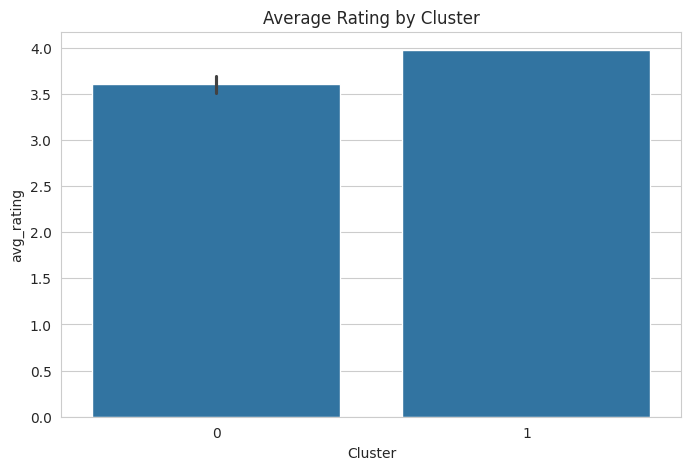

In [286]:
sns.barplot(
    x="Cluster",
    y="avg_rating",
    data=final_df
)

plt.title("Average Rating by Cluster")

plt.show()

**Review Length by Cluster**

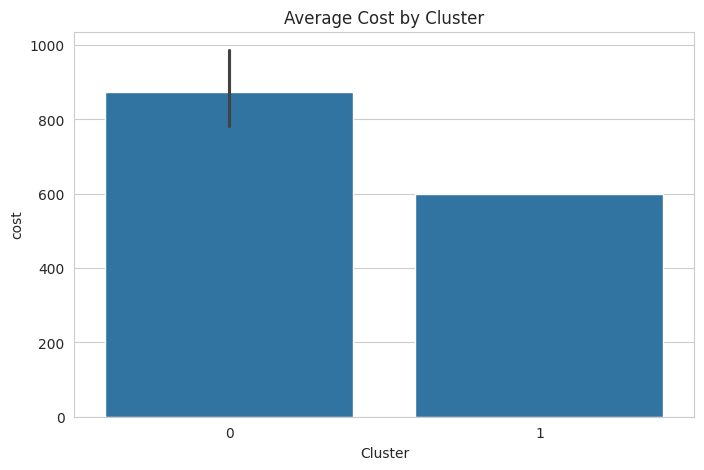

In [287]:
sns.barplot(
    x="Cluster",
    y="cost",
    data=final_df
)

plt.title("Average Cost by Cluster")

plt.show()

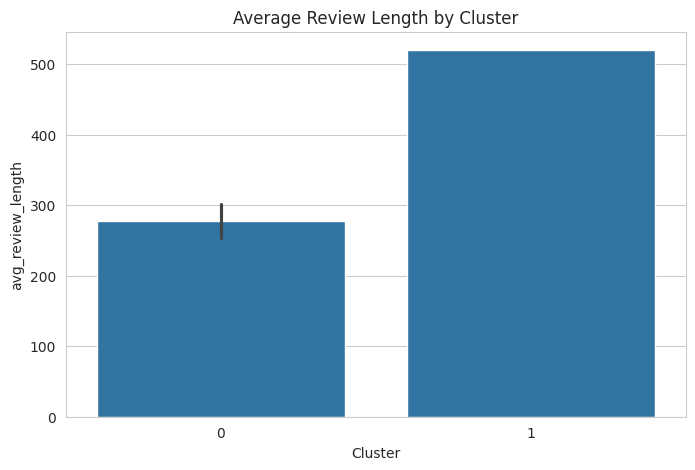

In [288]:
sns.barplot(
    x="Cluster",
    y="avg_review_length",
    data=final_df
)

plt.title("Average Review Length by Cluster")

plt.show()

#### **Cluster Interpretation**

**Cluster 0 — Premium Restaurants**

Characteristics:

````
Higher cost ,
Higher ratings ,
Longer reviews ,
More customer engagement
````

Meaning:
```
Popular premium dining restaurants
```

----

**Cluster 1 — Budget Restaurants**

Characteristics:

```
Lower cost
Moderate ratings
Shorter reviews
Lower engagement
```

Meaning:
```
Budget-friendly restaurants with average popularity
```

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**The primary evaluation metric used in this project was the Silhouette Scor**e.

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. It evaluates both cluster cohesion (how close data points are within the same cluster) and cluster separation (how distinct one cluster is from another).

The score ranges from -1 to 1, where:

*  Values closer to 1 indicate well-separated and clearly defined clusters.

*  Values around 0 indicate overlapping clusters.

*  Negative values indicate incorrect clustering.

Silhouette Score was chosen because clustering is an unsupervised learning problem, meaning there are no predefined labels or ground truth to compare predictions against. Therefore, traditional metrics such as accuracy, precision, or recall cannot be used.

Using the Silhouette Score helps ensure that the clusters formed represent meaningful and distinct restaurant segments, which is important for generating reliable business insights such as identifying groups of restaurants with similar pricing, customer engagement, and review patterns.

**In this project, the Agglomerative Hierarchical Clustering model achieved the highest Silhouette Score (~0.5566), indicating strong cluster separation and making it the most suitable model for identifying restaurant segments.**

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**The Agglomerative Hierarchical Clustering model (tuned) was selected as the final model.**

This decision was based on the Silhouette Score comparison across all models, where the tuned Hierarchical Clustering model achieved the **highest score of approximately 0.5566.**

**Model comparison:**

| Model                           | Silhouette Score |
| ------------------------------- | ---------------- |
| KMeans (Tuned)                  | ~0.2168          |
| Hierarchical Clustering (Tuned) | **~0.5566**      |
| Gaussian Mixture Model          | ~0.4457          |


The Hierarchical Clustering model performed the best because it was able to create more clearly separated clusters, indicating better grouping of restaurants with similar characteristics.

A higher Silhouette Score suggests that the clusters are internally cohesive and well-separated from other clusters, which leads to more reliable segmentation. This makes the Hierarchical model more effective for identifying meaningful restaurant groups based on features such as cost, ratings, review patterns, and customer feedback.

**Therefore, the tuned Agglomerative Hierarchical Clustering model was chosen as the final model for generating restaurant segments and business insights.**

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**The final model selected for this project was Agglomerative Hierarchical Clustering (Tuned Model).**

Hierarchical Clustering is an unsupervised learning algorithm that groups similar data points by gradually merging them into clusters based on a distance metric. In this project, the single linkage method was used, where clusters are formed by joining the two closest data points or clusters at each step.

The clustering process begins with each restaurant treated as an individual cluster. The algorithm then repeatedly merges the closest clusters until the desired number of clusters is formed. The relationships between clusters can be visualized using a dendrogram, which illustrates how clusters are hierarchically combined.

---

**Model Explainability Approach**

Since clustering models do not have built-in feature importance like supervised models, feature importance was interpreted using cluster profiling and feature distribution analysis.

Cluster profiling involves examining the average values of key features within each cluster to understand what differentiates the clusters.

**The important features identified through cluster profiling were:**

**1. Cost**

Cost showed significant variation across clusters and played a major role in distinguishing premium restaurants from budget restaurants. Restaurants with higher costs tended to form a separate segment.

**2. Average Rating**

Average rating helped differentiate restaurants based on customer satisfaction and perceived quality. Higher ratings were associated with restaurants receiving stronger customer engagement.

**3. Review Count**

Review count represented restaurant popularity and customer activity. Restaurants with higher review counts typically belonged to clusters with stronger customer engagement.

**4. Average Review Length**

Average review length captured the depth of customer feedback, indicating the level of engagement and detailed experiences shared by customers.

**5. PCA Components from Reviews**

Principal Component Analysis (PCA) components derived from TF-IDF features summarized patterns in customer reviews. These components helped capture differences in customer sentiments, food quality mentions, and service experiences, which contributed to cluster differentiation.

---

**Interpretation**

By analyzing the feature distributions across clusters, it was observed that the clustering model primarily separated restaurants based on pricing, customer satisfaction, and review engagement patterns. These features collectively helped identify meaningful restaurant segments within the d

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The objective of this project was to analyze Zomato restaurant data and segment restaurants into meaningful groups based on customer behavior, pricing, and review patterns. By combining restaurant metadata with customer review information, the study aimed to identify patterns that could help understand restaurant performance and customer preferences.

During the analysis, textual customer reviews were transformed into numerical features using TF-IDF, and Principal Component Analysis (PCA) was applied to reduce the high dimensionality of the text data while retaining most of the important information. The dataset was then standardized using StandardScaler to ensure that all features contributed equally to the clustering process.

Three clustering models were implemented and compared: KMeans Clustering, Agglomerative Hierarchical Clustering, and Gaussian Mixture Model. The models were evaluated using the Silhouette Score, which measures the quality of clustering by assessing both cluster cohesion and separation.

Among the tested models, the tuned Agglomerative Hierarchical Clustering model achieved the best performance with a Silhouette Score of approximately 0.5566, indicating well-defined and clearly separated clusters. This model was therefore selected as the final clustering model.

The clustering results revealed distinct restaurant segments based on features such as cost, customer ratings, review count, and review characteristics. These clusters represent different restaurant categories in terms of pricing, customer engagement, and overall popularity.

Overall, the clustering approach successfully identified meaningful restaurant segments, providing insights into how restaurants differ in terms of customer perception and pricing strategy. These insights can help better understand restaurant performance patterns across the dataset.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***